# Code demonstrating QFT and inverse QFT

The code here demonstrates the Quantum Fourier Transform (QFT) and its inverse, and is based on the following <a href="https://quantum.cloud.ibm.com/learning/en/modules/computer-science/qft">Qiskit learning material</a>.
This demonstration makes use of the simulator functionality of qiskit_ibm_runtime and qiskit_aer.

# Boilerplate code

In [1]:
# Boilerplate to run 
## Qiskit stuff
from qiskit import QuantumCircuit 
from qiskit.circuit.library import QFTGate
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Import a local fake backend instead of using QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit.primitives import BackendSamplerV2

# Load the Aer simulator and generate a noise model locally
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

# Instantiate the fake backend (no cloud connection required)
backend = FakeManilaV2()

# Generate the noise model based on the local fake backend
noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

## Other stuff for image generation
import numpy as np
from IPython.display import display
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt 
import matplotlib.patches as patches

# This style sheet is in use.
plt.style.use('../intro_to_qml_figure_style.mpltstyle') 
import warnings 
warnings.filterwarnings( # Filter out the specific tight_layout warning generated by Jupyter/Matplotlib 3D plots
    "ignore", 
    category=UserWarning, 
    message="This figure includes Axes that are not compatible with tight_layout"
)
figure_directory = '../Figures/Ch2_Quantum_Algorithms_Figures/'

def plot_histogram_reversed(counts, title=None, font_size=10):
    """Helper to reverse bitstrings (q_0 -> q_n) and apply custom font sizing."""
    # Reverse key bitstrings
    rev_counts = {k[::-1]: v for k, v in counts.items()}
    
    # Temporarily set styling context for this figure only
    with plt.rc_context({
        'font.size': font_size,
        'axes.titlesize': font_size + 2,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size - 1,
        'ytick.labelsize': font_size - 1
    }):
        return plot_histogram(rev_counts, title=title)


# Visualisation of QFT and inverse QFT circuits

A useful part of Qiskit is that it lets circuits be decomposed.
For example for the 4 qubit case we get the following.

Note here that the ordering of qubit states is inverted compared to the <a href="https://pranav-acharya.com/intro_to_QML/Ch2_simple_quantum_algorithms.html#QFT_subsection">tutorial</a>, so for drawing circuits 'reverse_bits=True' is used to make it match the previously created figures.
So for the forward QFT circuit, this means that the Hadamard is first applied on the qubit $q_3$ instead of $q_0$.

Another difference from <a href="https://pranav-acharya.com/intro_to_QML/Ch2_simple_quantum_algorithms.html#QFT_subsection">tutorial</a> is that the controlled-phase rotational gates are labelled 'P' instead of 'R'.

/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/2576494257.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


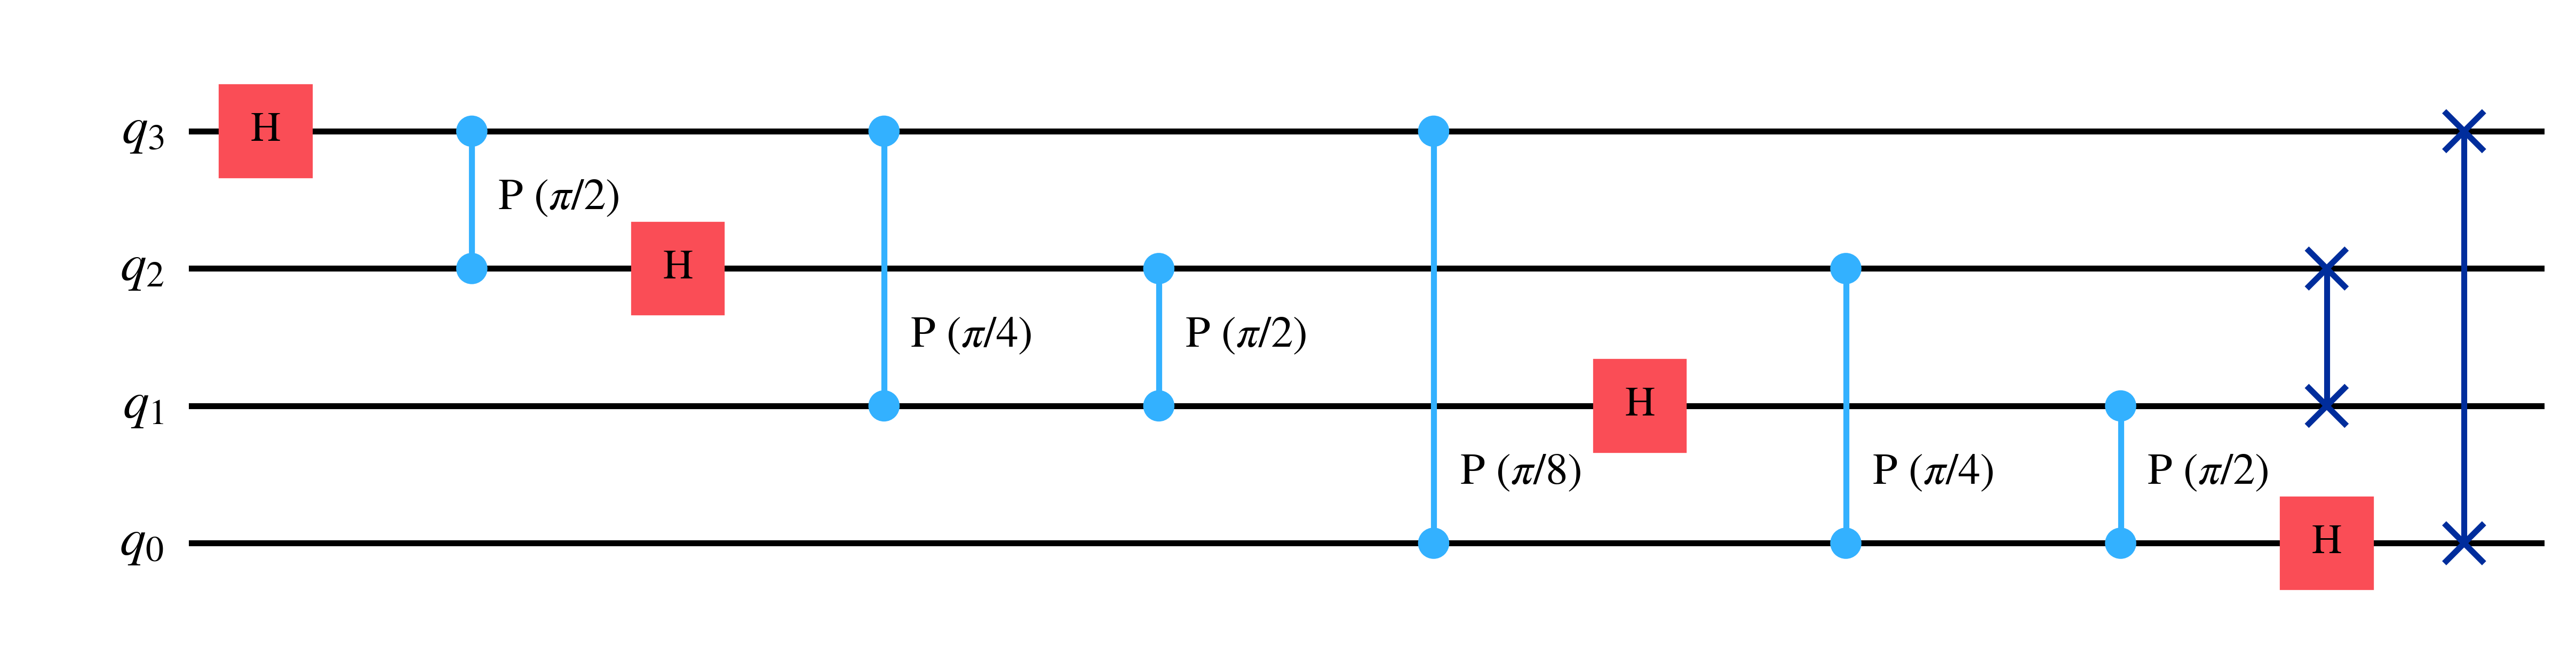

In [2]:
# QFT

# Define style dictionary to increase gate font size
qiskit_style = {
    'fontsize': 14,        # Default is 13; increase this value for larger gate text
    'subfontsize': 15      # Default is 8; Controls subscript text size (e.g., control indices or parameters)
}

qc_QFT = QuantumCircuit(4)
qc_QFT.compose(QFTGate(4), inplace=True)
fig = qc_QFT.decompose().draw("mpl", style=qiskit_style, reverse_bits=True)
# fig.savefig(figure_directory+'expanded_QFT_circuit.png', bbox_inches='tight')
fig.show()

/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/270091884.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


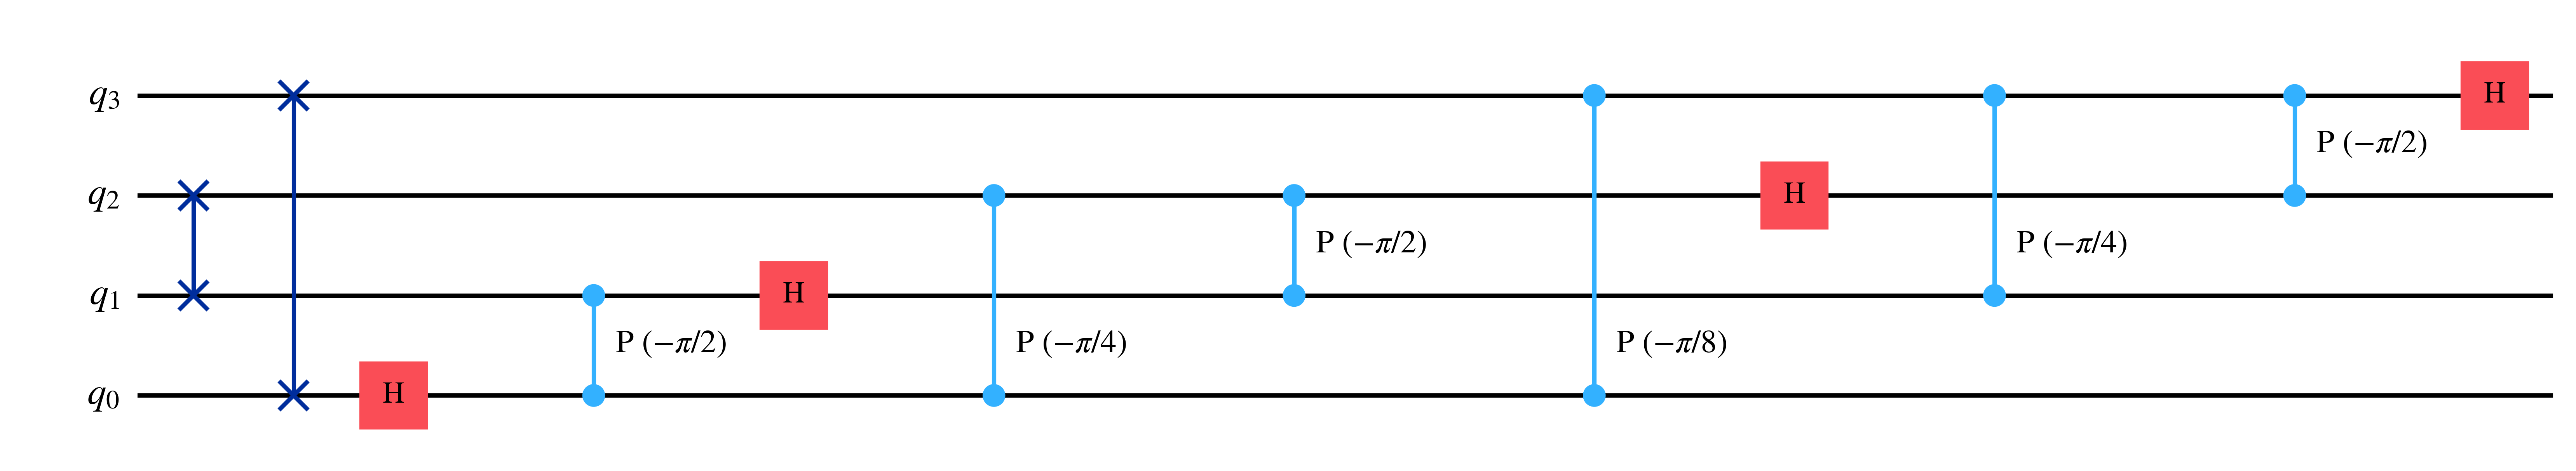

In [3]:
# QFT

# Define style dictionary to increase gate font size
qiskit_style = {
    'fontsize': 14,        # Default is 13; increase this value for larger gate text
    'subfontsize': 15      # Default is 8; Controls subscript text size (e.g., control indices or parameters)
}

qc_inverse_QFT = QuantumCircuit(4)
qc_inverse_QFT.compose(QFTGate(4).inverse(), inplace=True)
fig = qc_inverse_QFT.decompose().draw("mpl", style=qiskit_style, reverse_bits=True)
# fig.savefig(figure_directory+'expanded_inverse_QFT_circuit.png', bbox_inches='tight')
fig.show()

# Demonstration of QFT

Here the QFT and inverse QFT are shown on different states. Note, that this time the qubit registers are not reversed, so $q_0$ appears above. But for sake of ease of understanding, the states in the histogram will be ordered so $q_0$ is the first state (achieved with the function plot_histogram_reversed) 

## Prepared state $\ket{0001}$
### Preparation and Measurement of $\ket{0001}$
Let's begin with a basic state $\ket{1000}$, and show what it looks like

/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/196552010.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


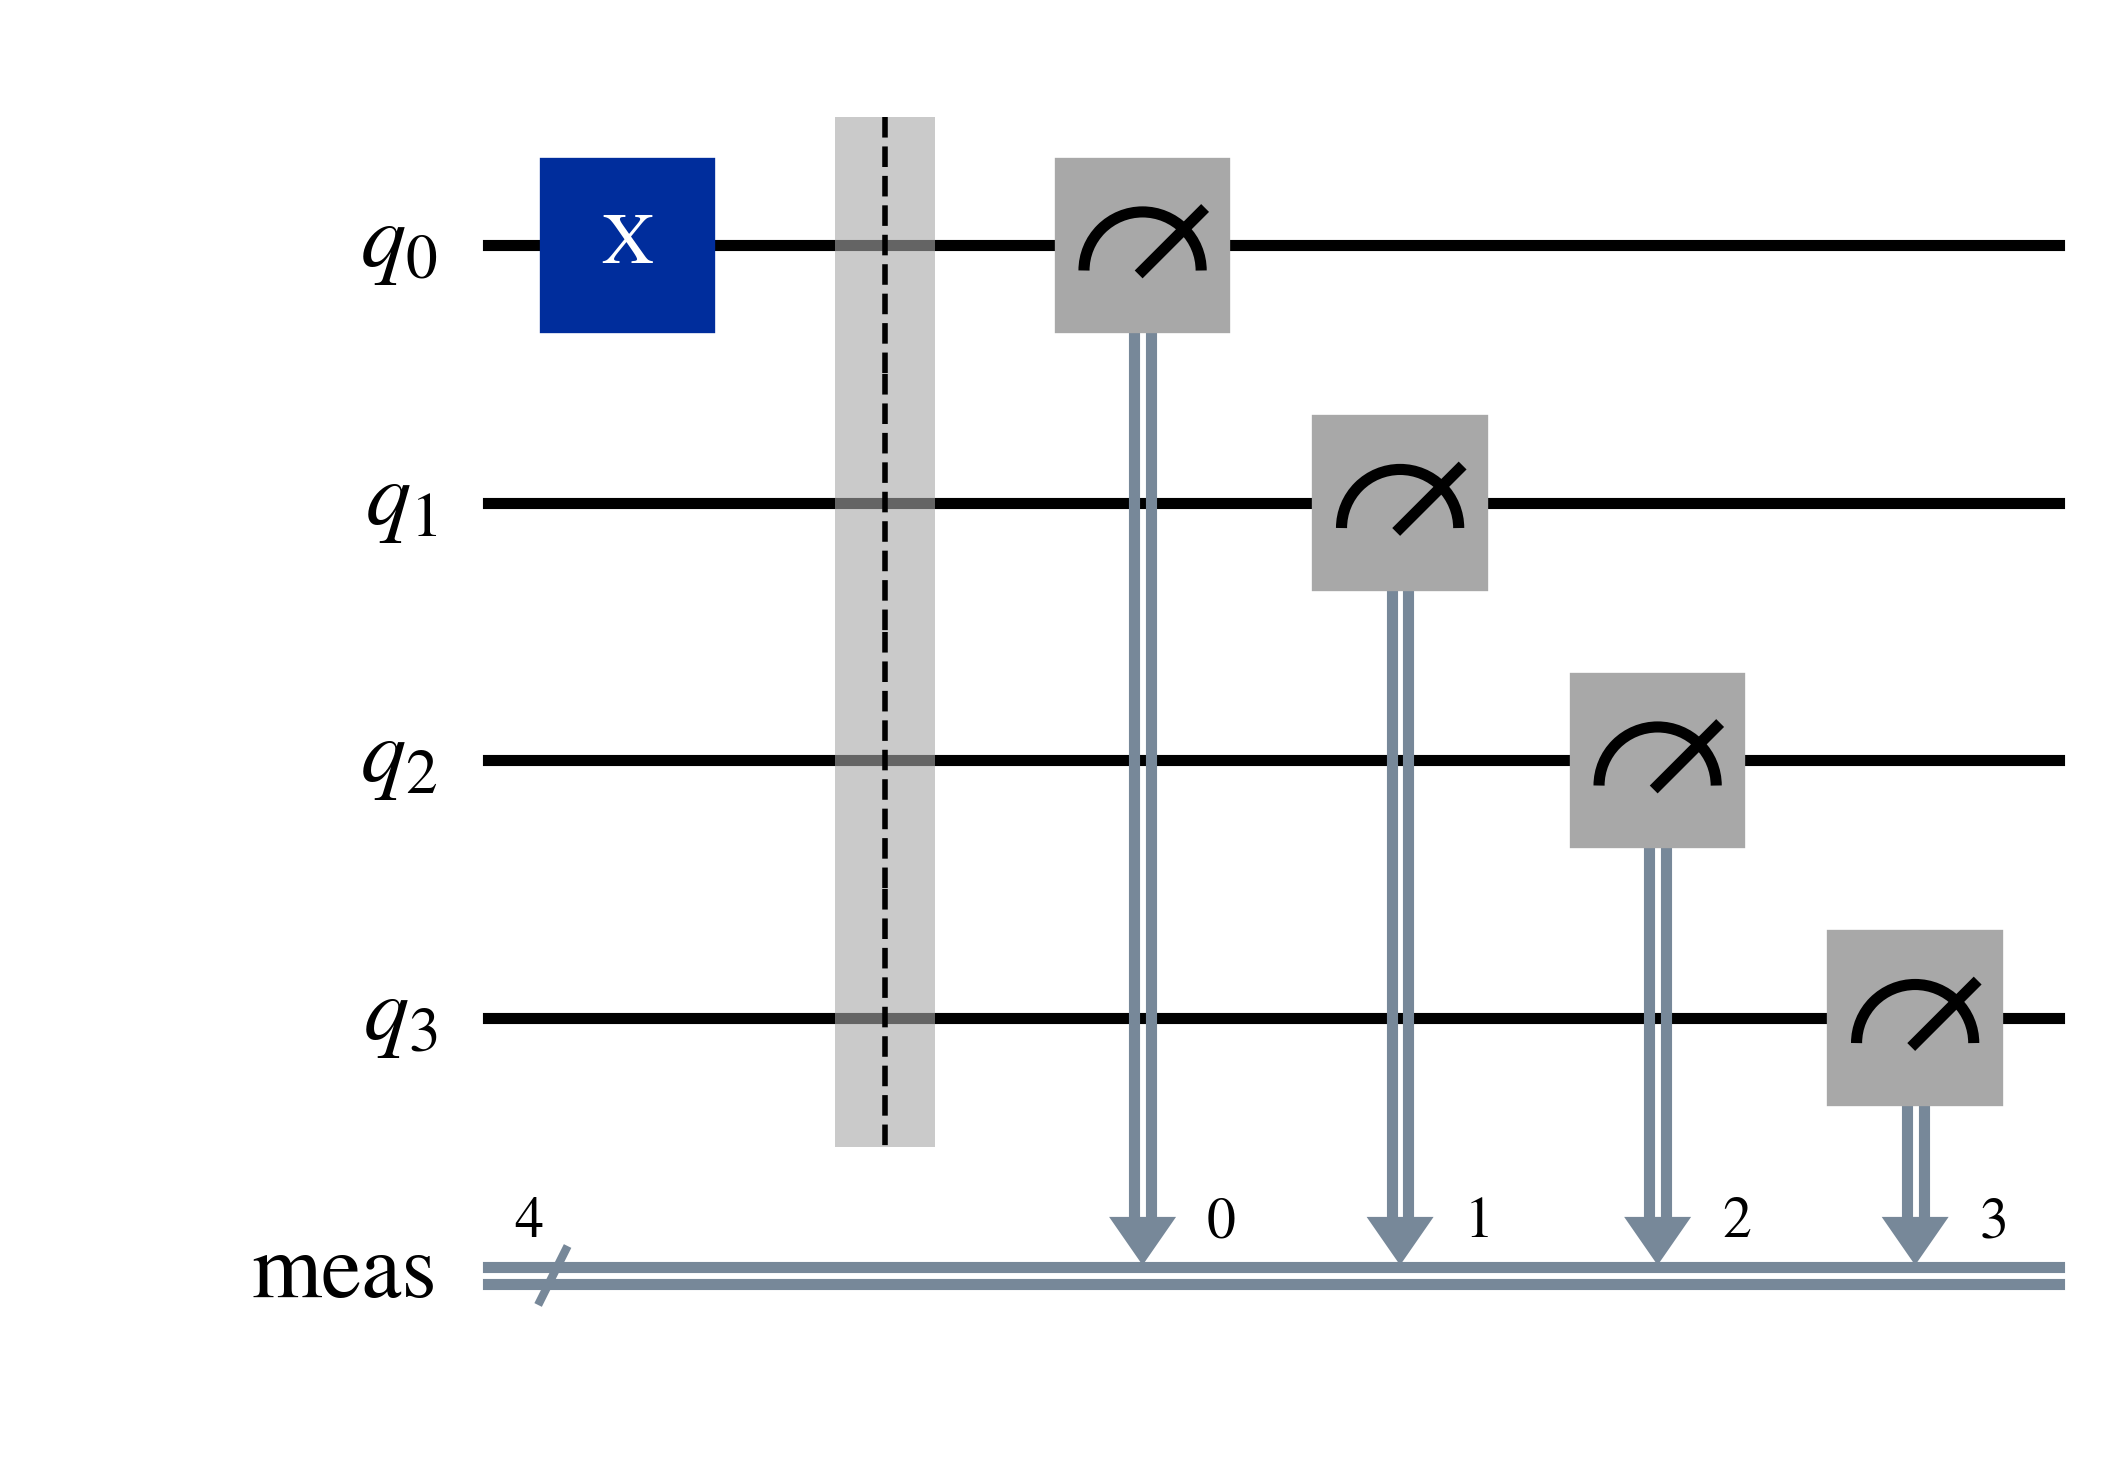

In [ ]:
# Step 1: Create circuit with 4 qubits
qubits
qc = QuantumCircuit(qubits)
qc.x(0)

qc.measure_all()
fig=qc.draw("mpl")
fig.show()

Now let's transpile and run the circuit.
Further details on transpilation can be found in the Qiskit documentation <a href="https://quantum.cloud.ibm.com/docs/en/guides/transpile">here</a>, but in brief it is a rewriting of the circuit to match the actual hardware (simulated in this case) that the algorithm is chosen to run on. 

In [5]:
# Step 2: Transpile
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

# Step 3: Run the job on the Aer simulator with noise model from real backend
job = sampler_sim.run([qc_isa])
res = job.result()
counts = res[0].data.meas.get_counts()

Now let's visualise and see what we get. Note, that because of Qiskit's somewhat counterintuitive default ordering of states, with $q_0$ appearing at the end, a function 'plot_histogram_reversed' has been defined to reverse the order of states.

/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/3786847857.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


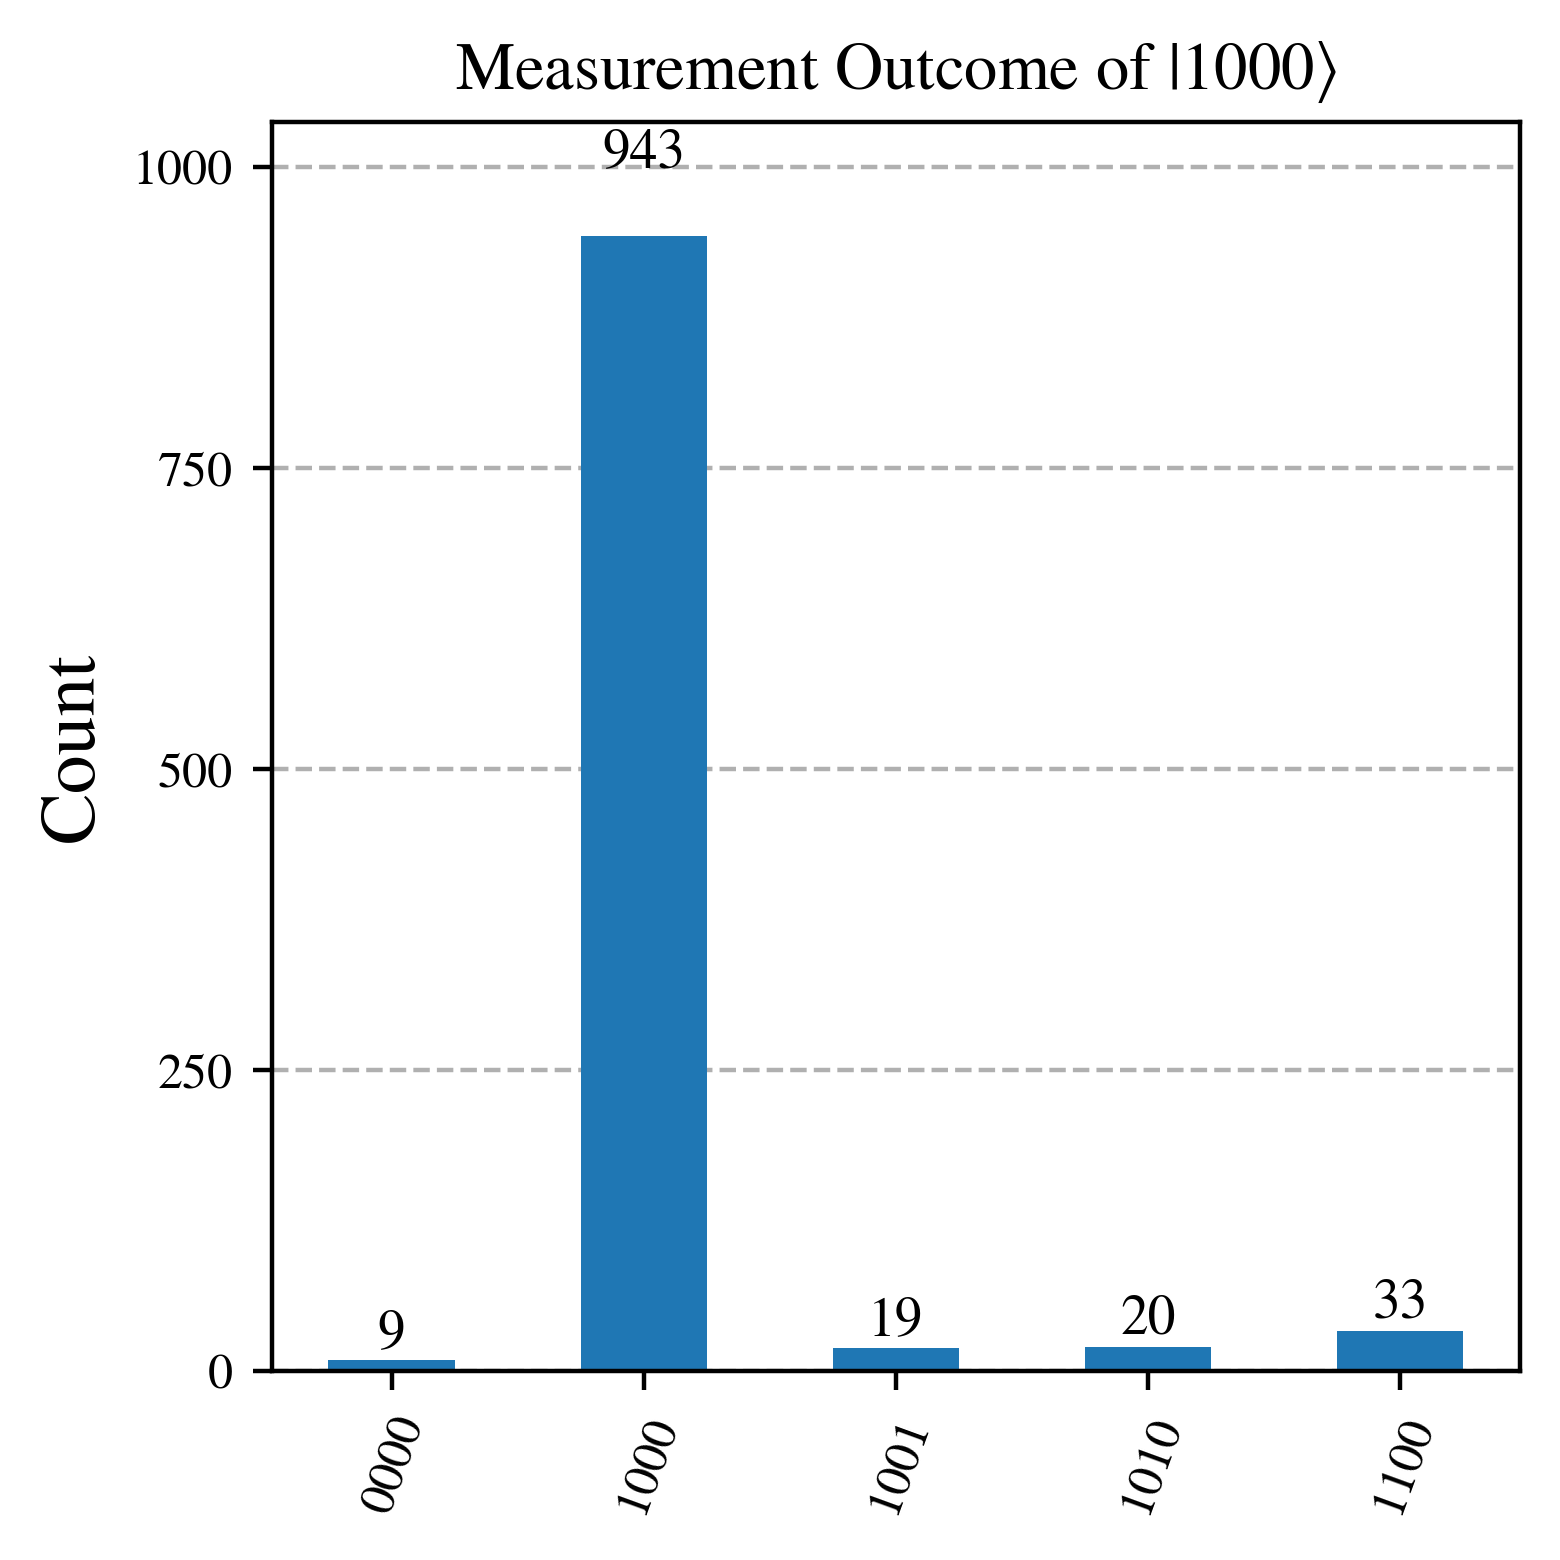

In [6]:
# Step 4: Visualise
# Display the figure
fig = plot_histogram_reversed(counts, title=r"Measurement Outcome of $\vert 1000 \rangle$")
fig.show()

### Application of QFT to $\ket{0001}$

Now let's repeat all those steps, this time with QFT applied

/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/975789291.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/975789291.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


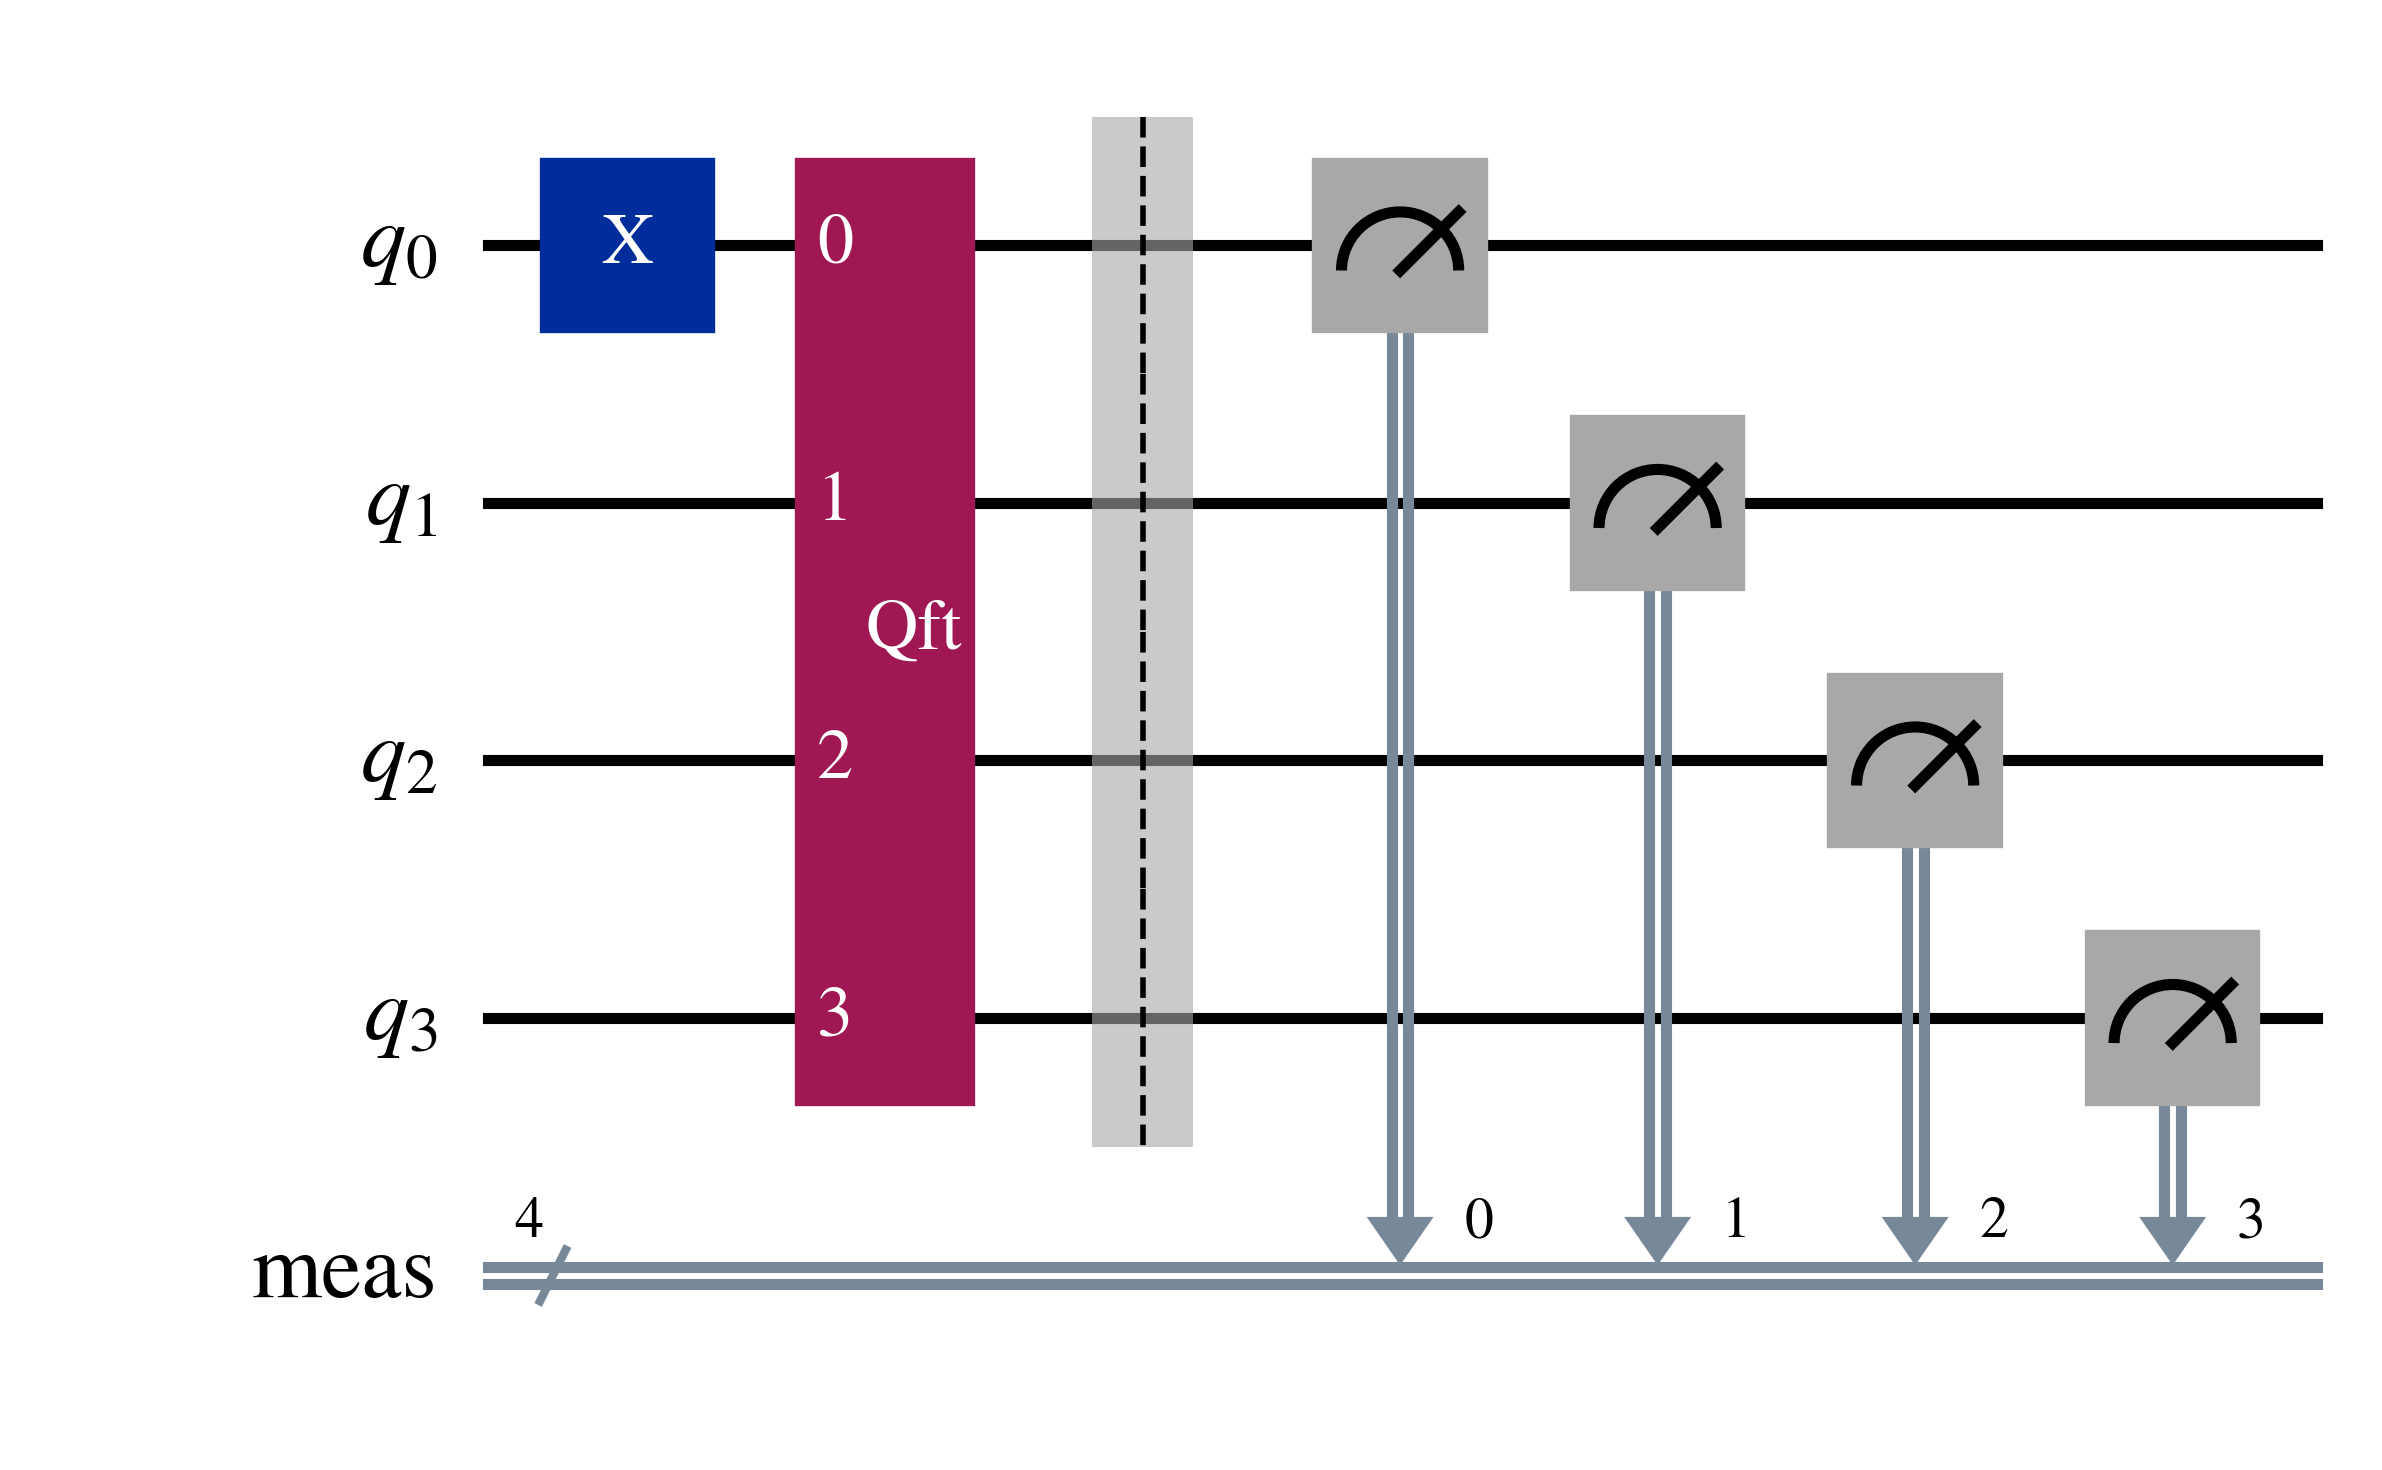

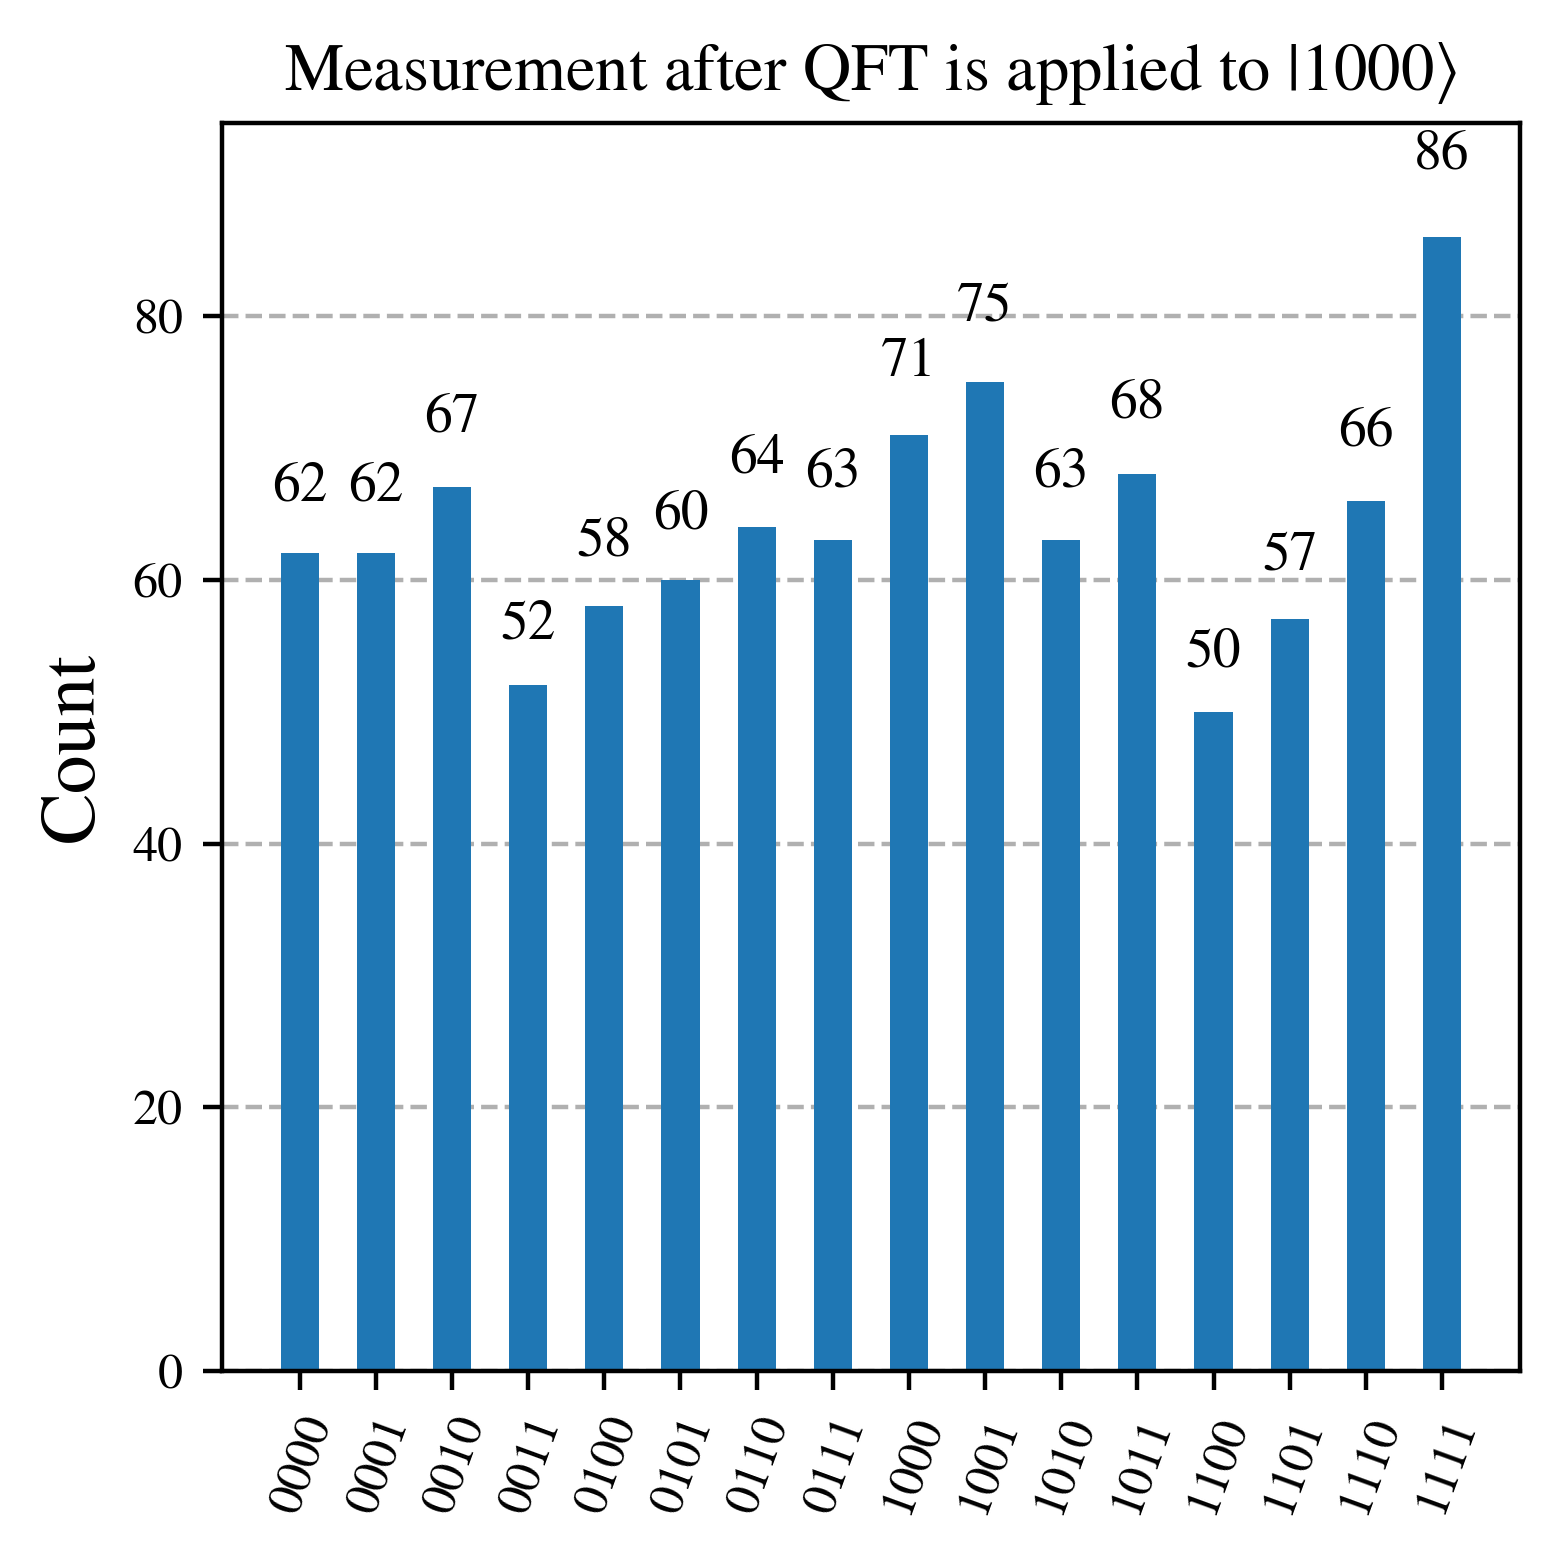

In [9]:
# Step 1: Create circuit
qc_qft = QuantumCircuit(4)
qc_qft.x(0)
qc_qft.compose(QFTGate(qubits), inplace=True)
qc_qft.measure_all()
fig=qc_qft.draw("mpl")
fig.show()

# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_qft)

# Step 3: Run the job on the Aer simulator with noise model from real backend

job = sampler_sim.run([qc_isa])
res = job.result()
counts = res[0].data.meas.get_counts()

# Step 4: Post-Process
fig= plot_histogram_reversed(counts, title=r"Measurement after QFT is applied to $\vert 1000 \rangle$")
fig.show()

### Application of inverse QFT following QFT

/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/3286984864.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/3286984864.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


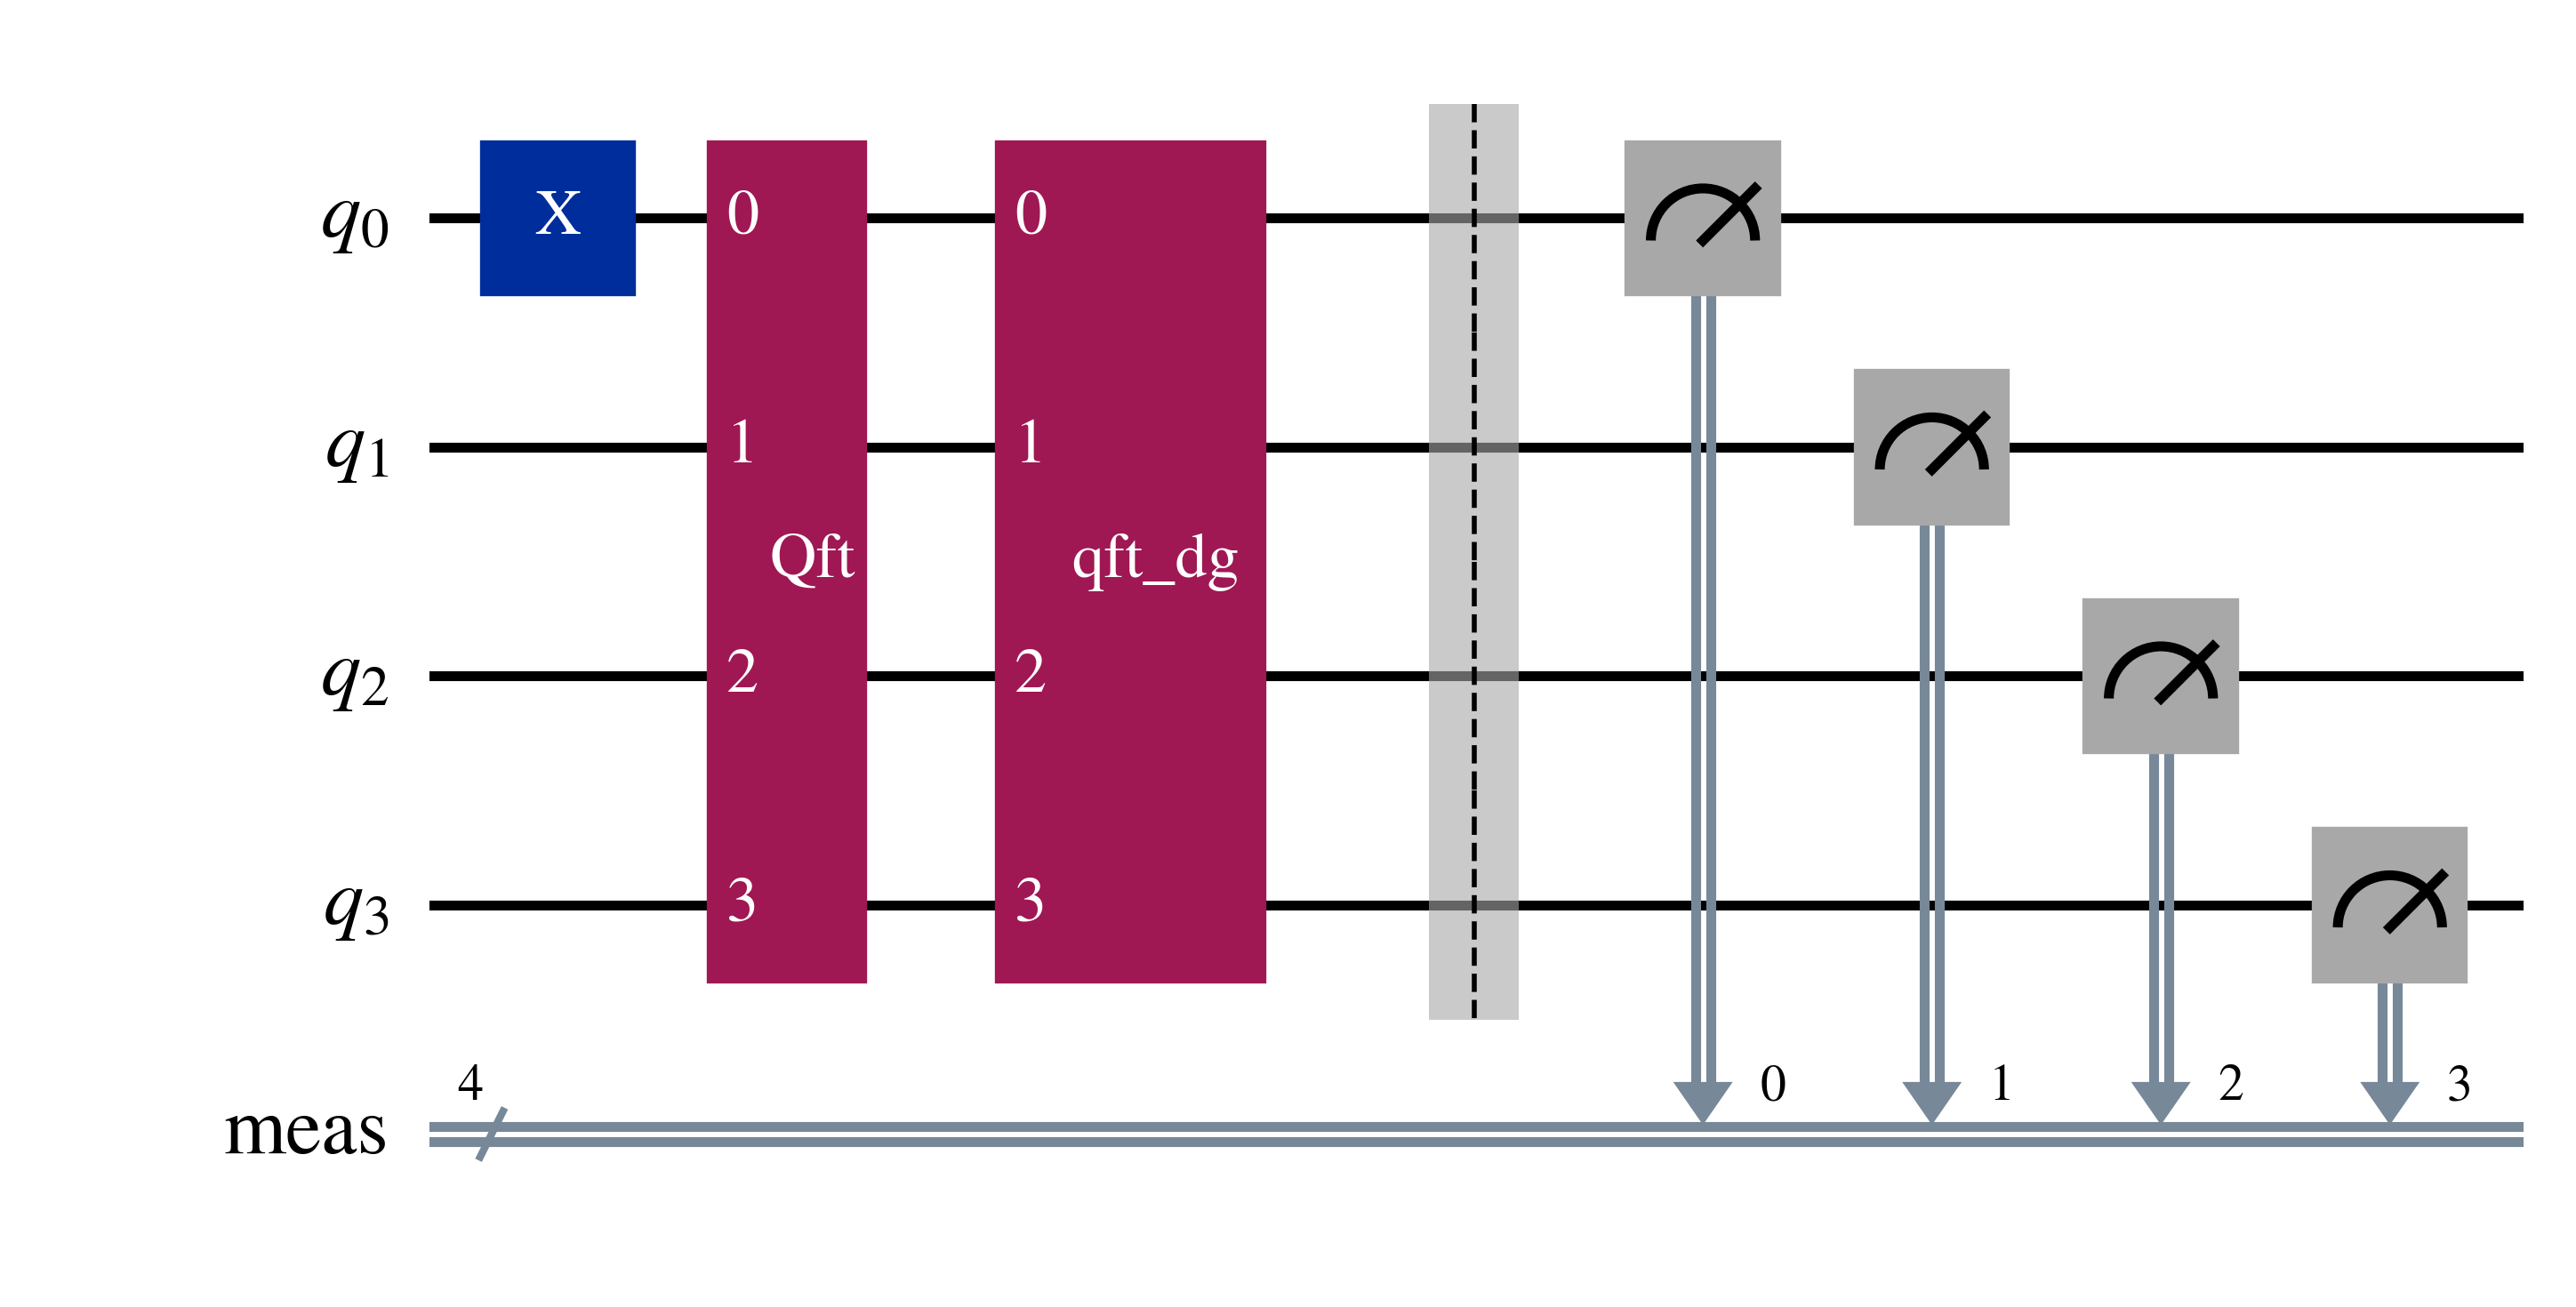

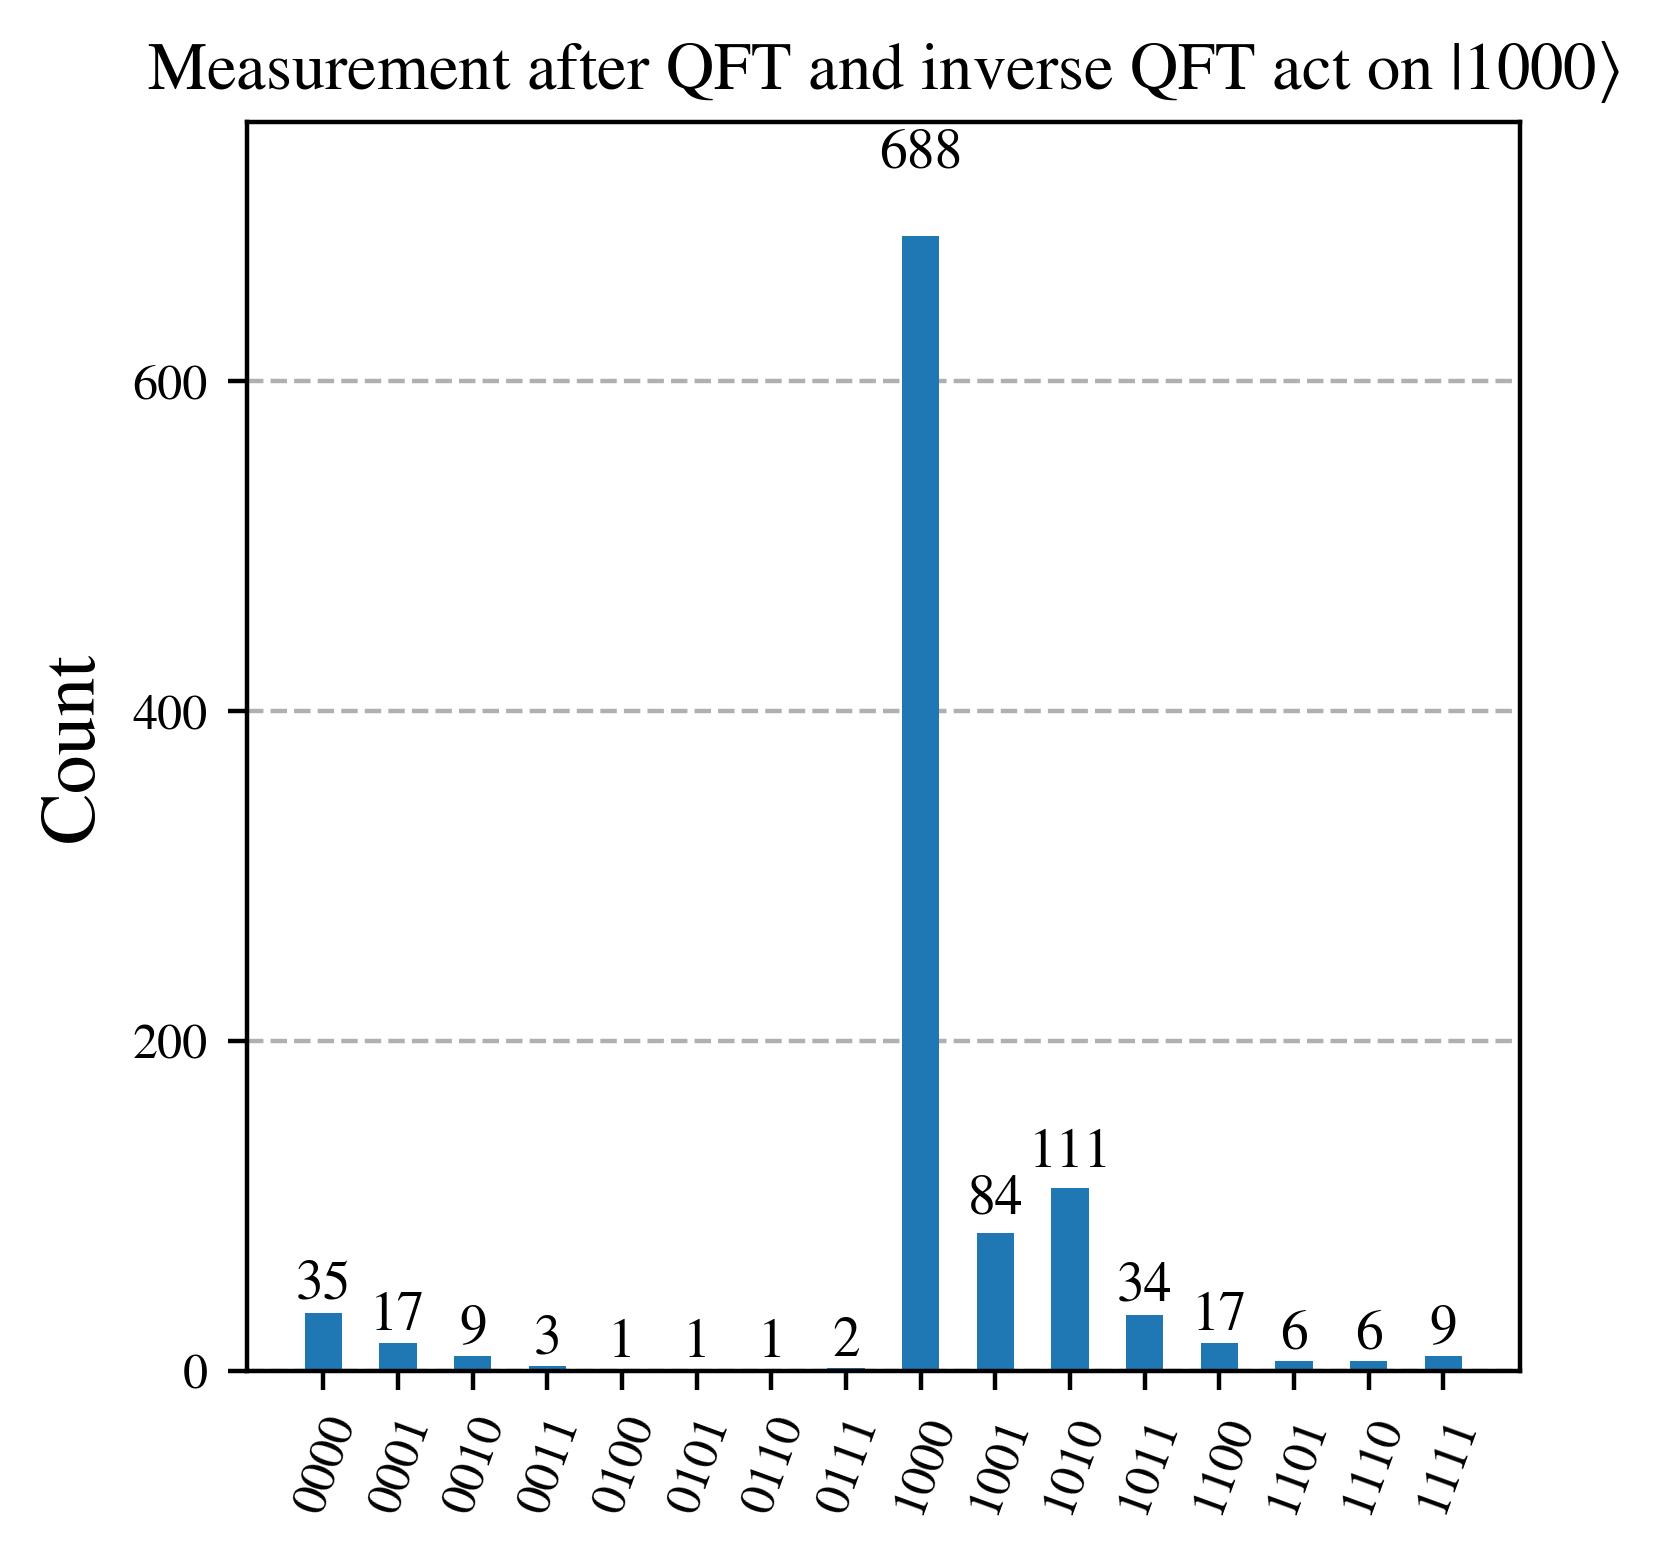

In [11]:
# Step 1: Create circuit
qc_qft = QuantumCircuit(4)
qc_qft.x(0)
qc_qft.compose(QFTGate(qubits), inplace=True)
qc_qft.compose(QFTGate(qubits).inverse(), inplace=True)
qc_qft.measure_all()
fig=qc_qft.draw("mpl")
fig.show()

# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_qft)

# Step 3: Run the job on the Aer simulator with noise model from real backend

job = sampler_sim.run([qc_isa])
res = job.result()
counts = res[0].data.meas.get_counts()

# Step 4: Post-Process
fig= plot_histogram_reversed(counts, title=r"Measurement after QFT and inverse QFT act on $\vert 1000 \rangle$")
fig.show()

As expected, the inverse QFT reverts the effects of QFT.
Though you will likely see a lower measurement count for the ideal state of $\ket{1000}$ because of the noise introduced by applying all the gates for the forward and inverse QFT.

## Prepared state $\frac{1}{\sqrt{2}}(\ket{0000} + \ket{1000})$
Now let's look at a state in superposition, $\frac{1}{\sqrt{2}}(\ket{0000} + \ket{1000})$

### Base state

/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/631321998.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/631321998.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


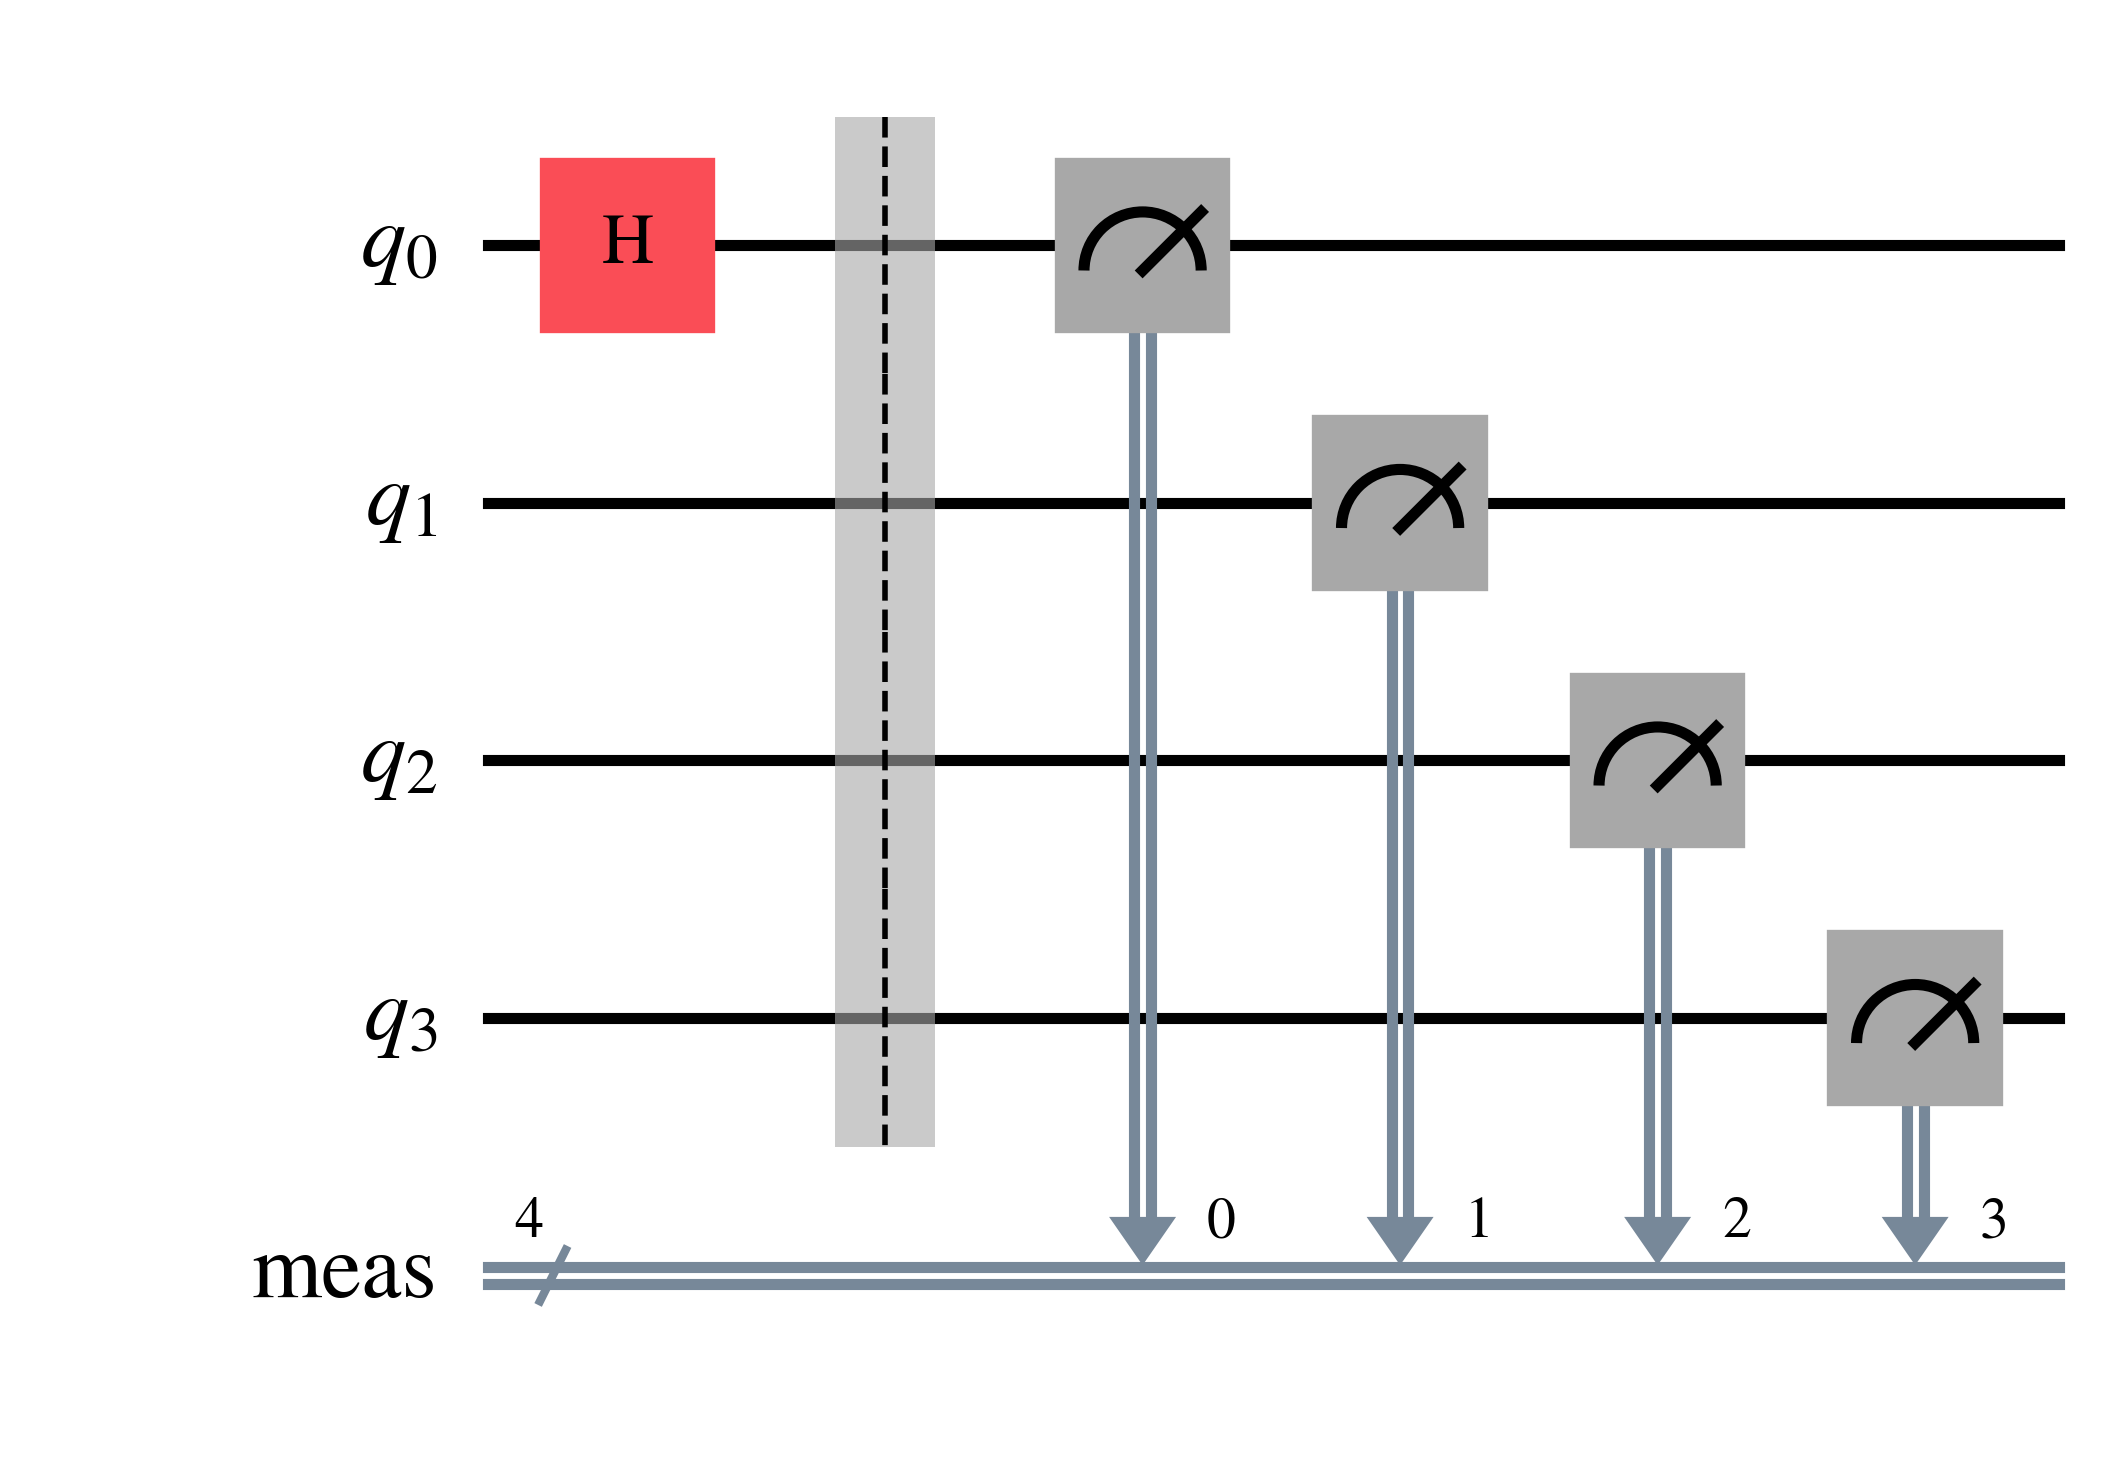

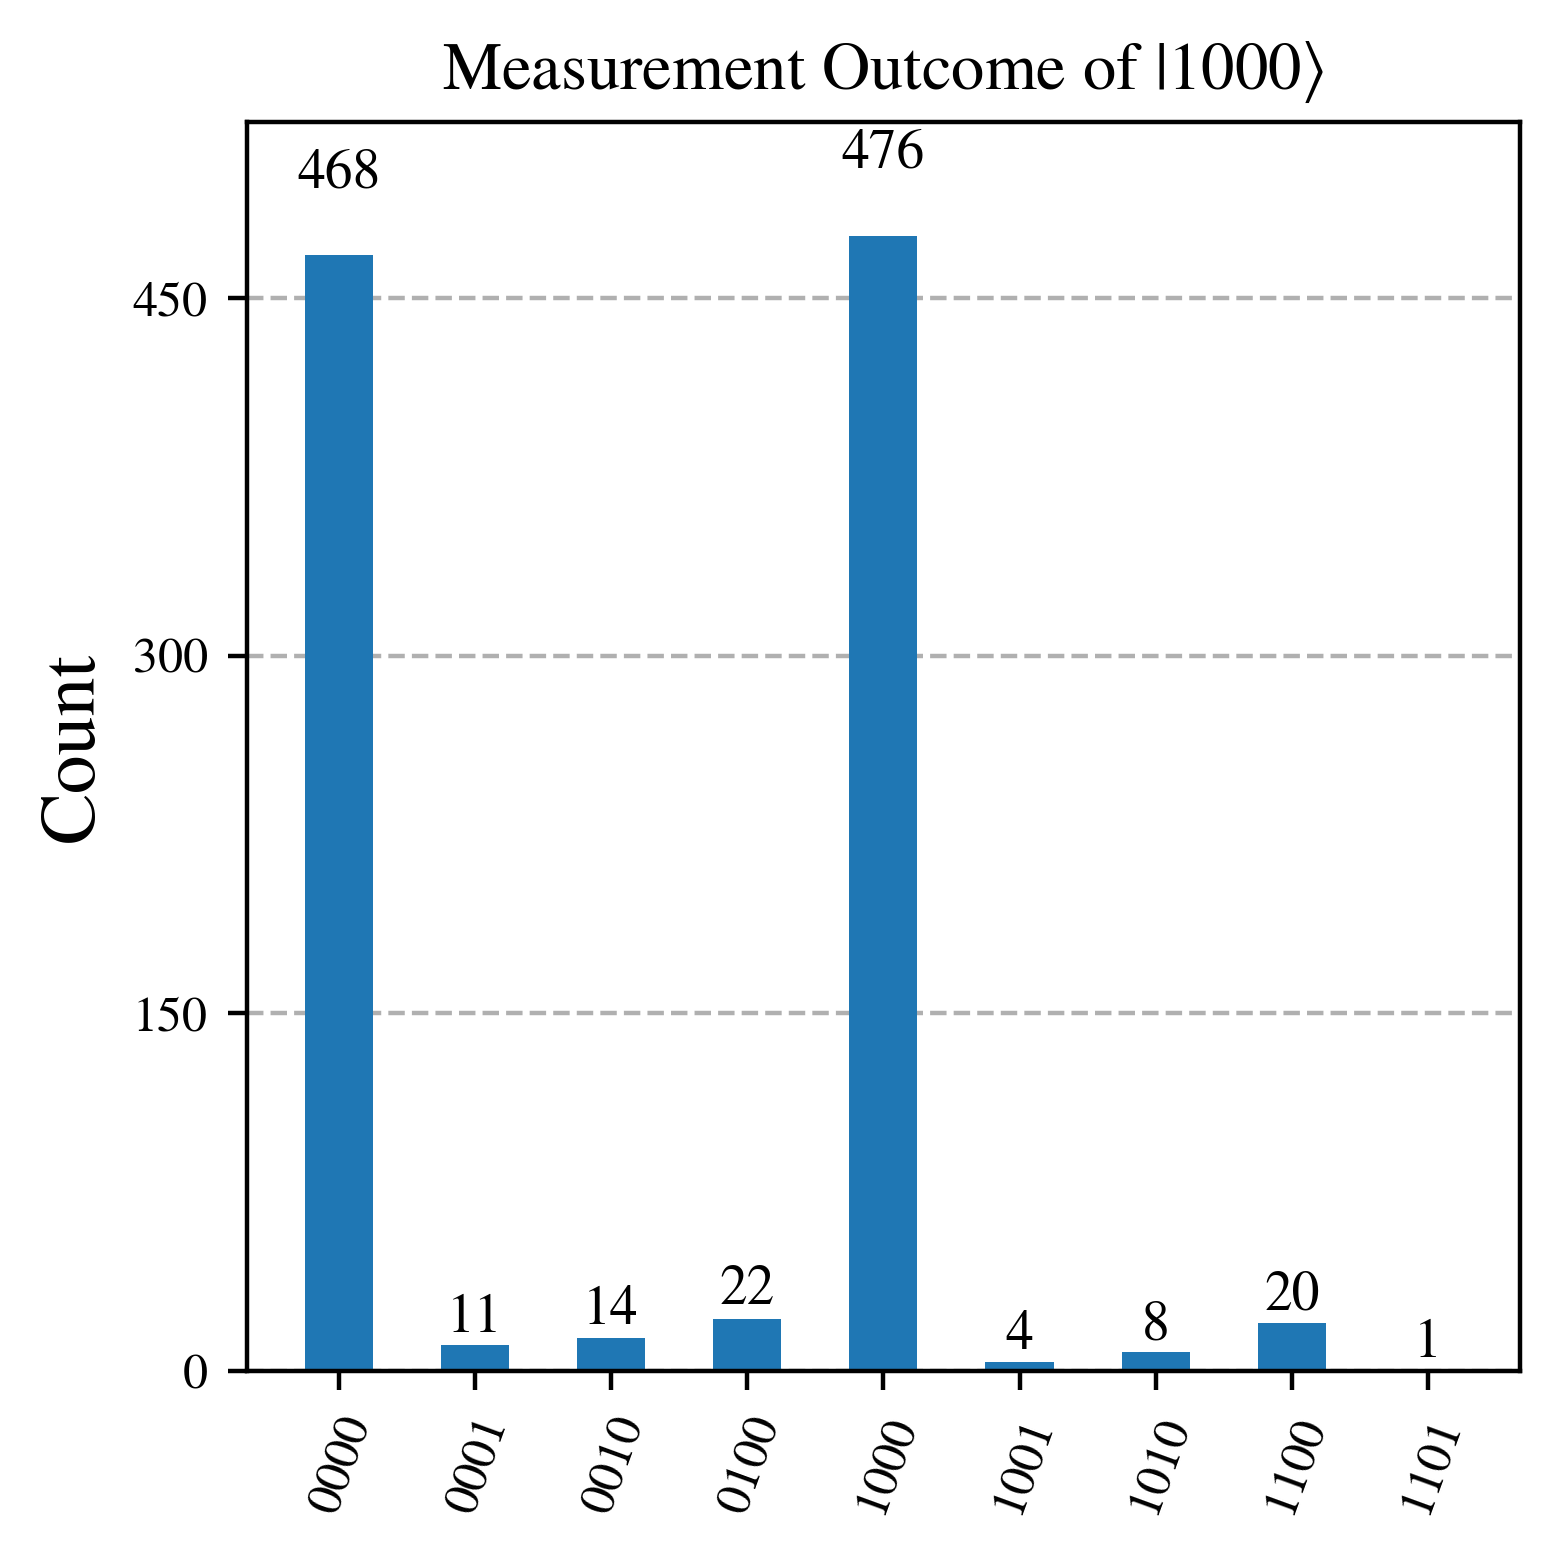

In [12]:
# Step 1: Create circuit with 4 qubits
qubits
qc = QuantumCircuit(qubits)
qc.h(0)

qc.measure_all()
fig=qc.draw("mpl")
fig.show()

# Step 2: Transpile
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

# Step 3: Run the job on the Aer simulator with noise model from real backend
job = sampler_sim.run([qc_isa])
res = job.result()
counts = res[0].data.meas.get_counts()

# Step 4: Visualise
# Display the figure
fig = plot_histogram_reversed(counts, title=r"Measurement Outcome of $\vert 1000 \rangle$")
fig.show()

### QFT

/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/1020324574.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/1020324574.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


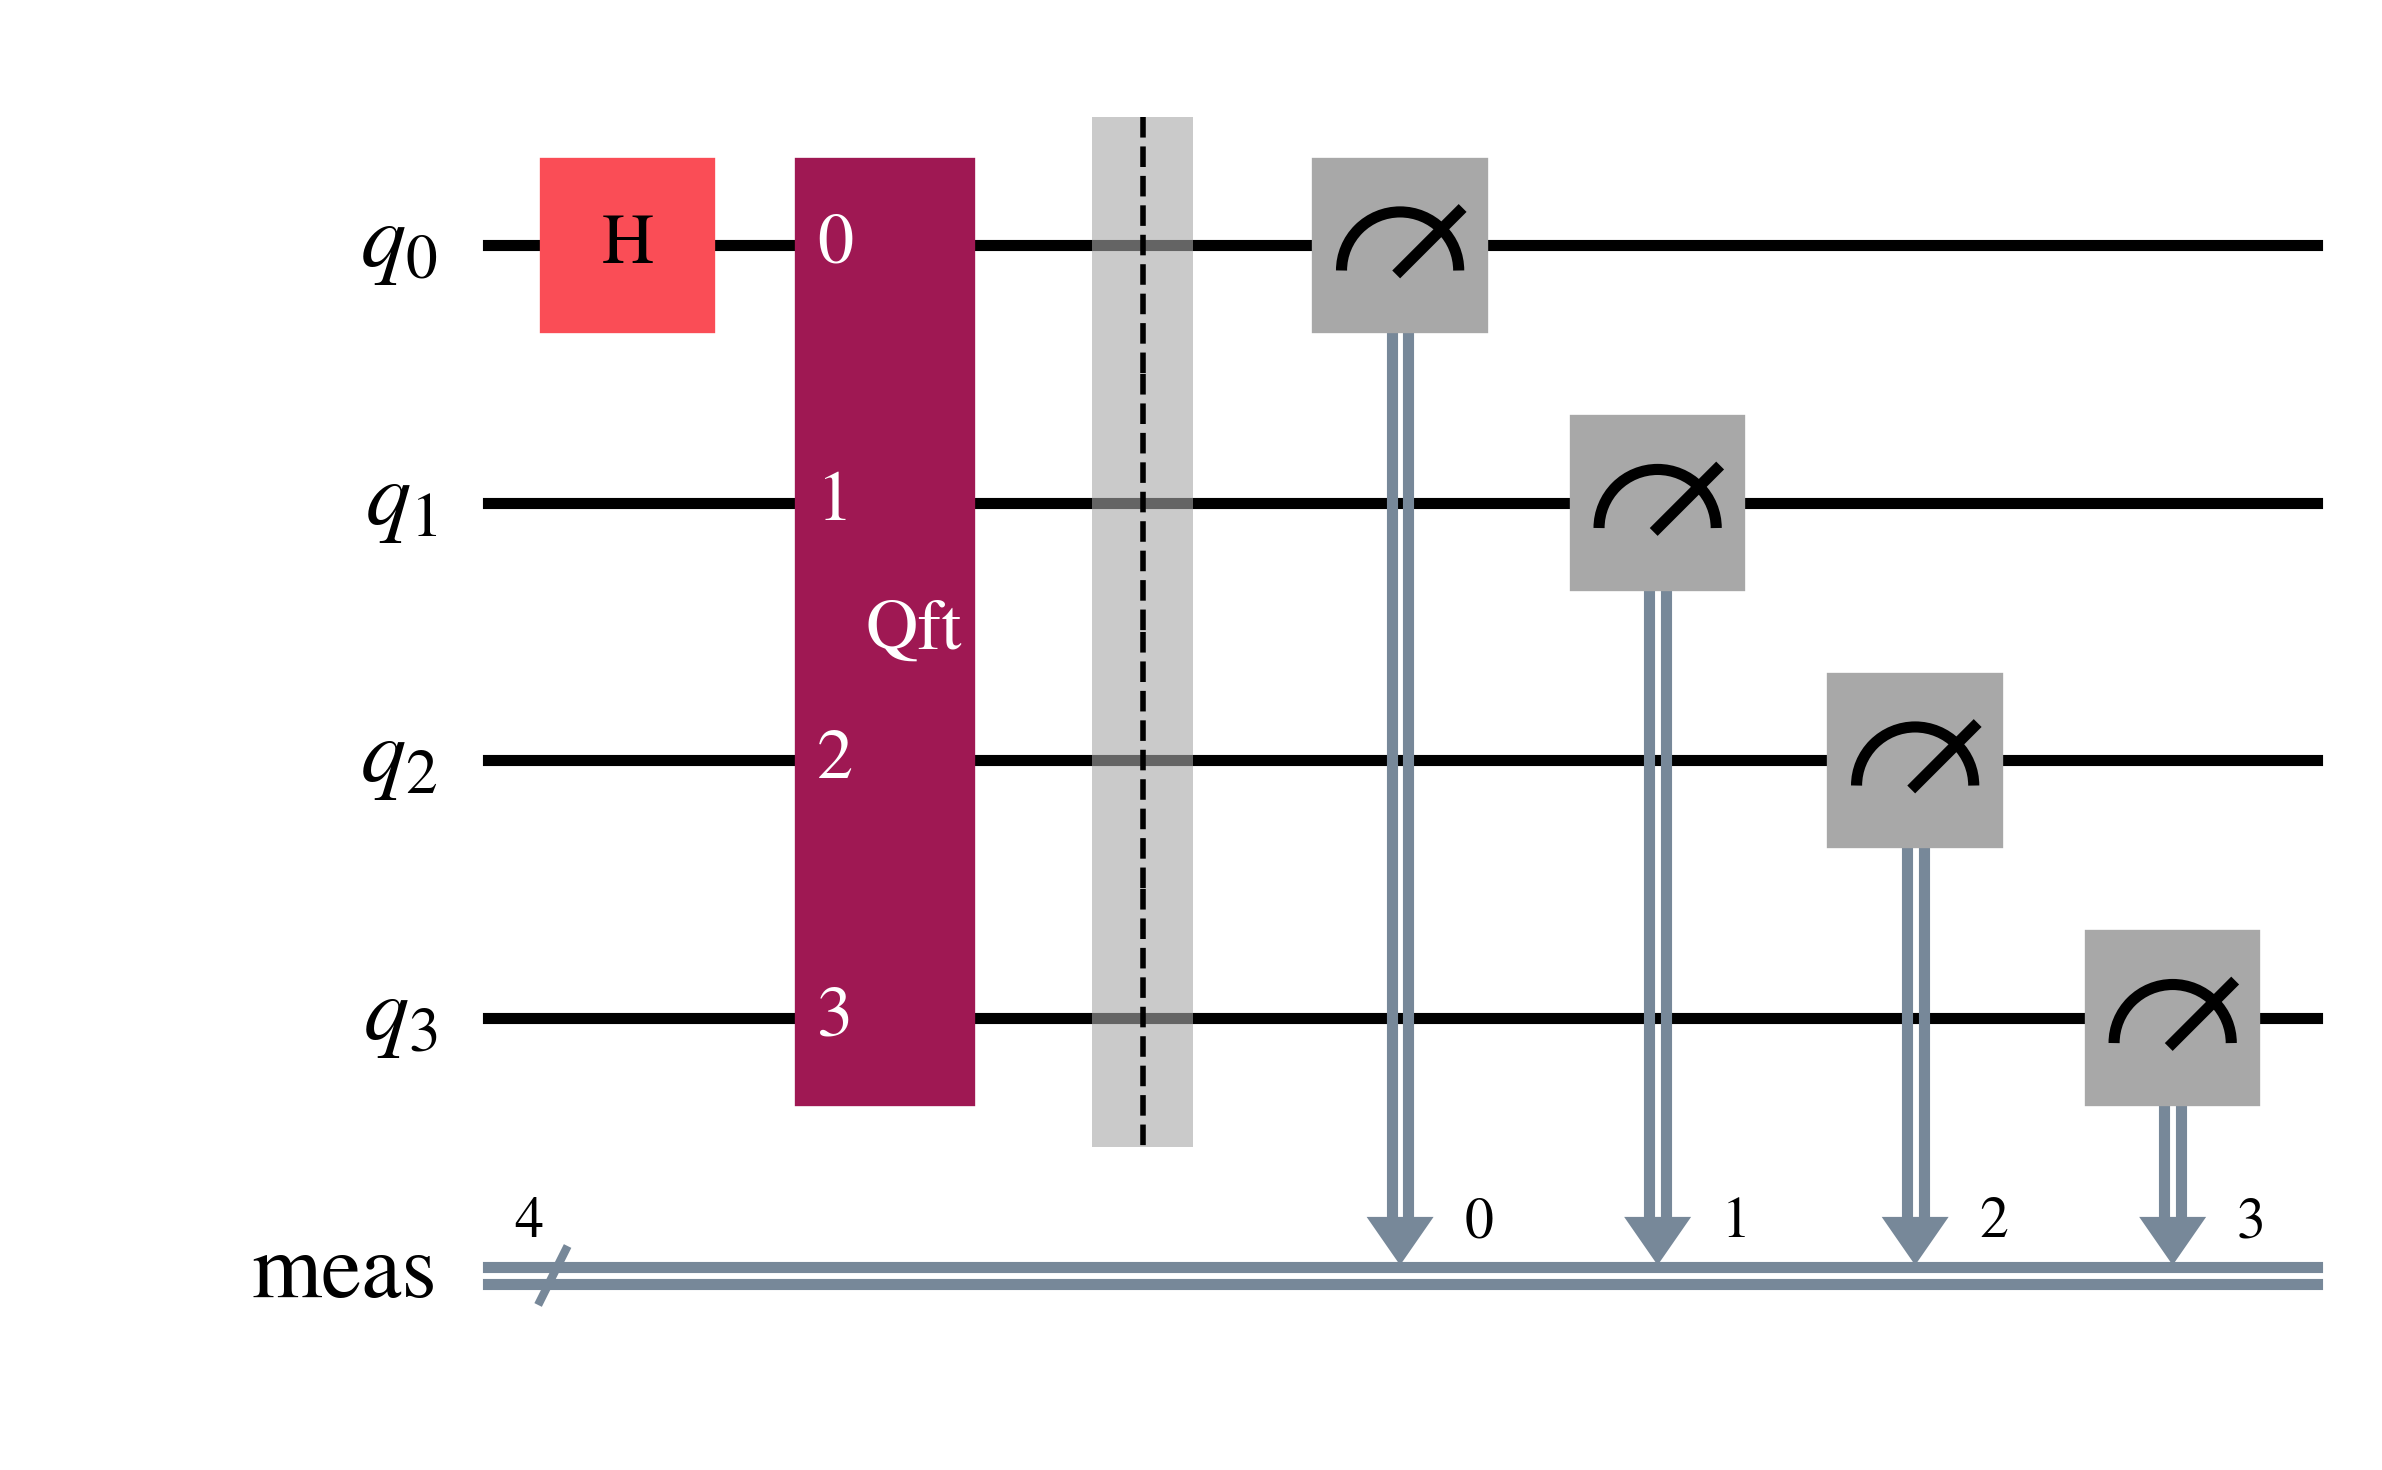

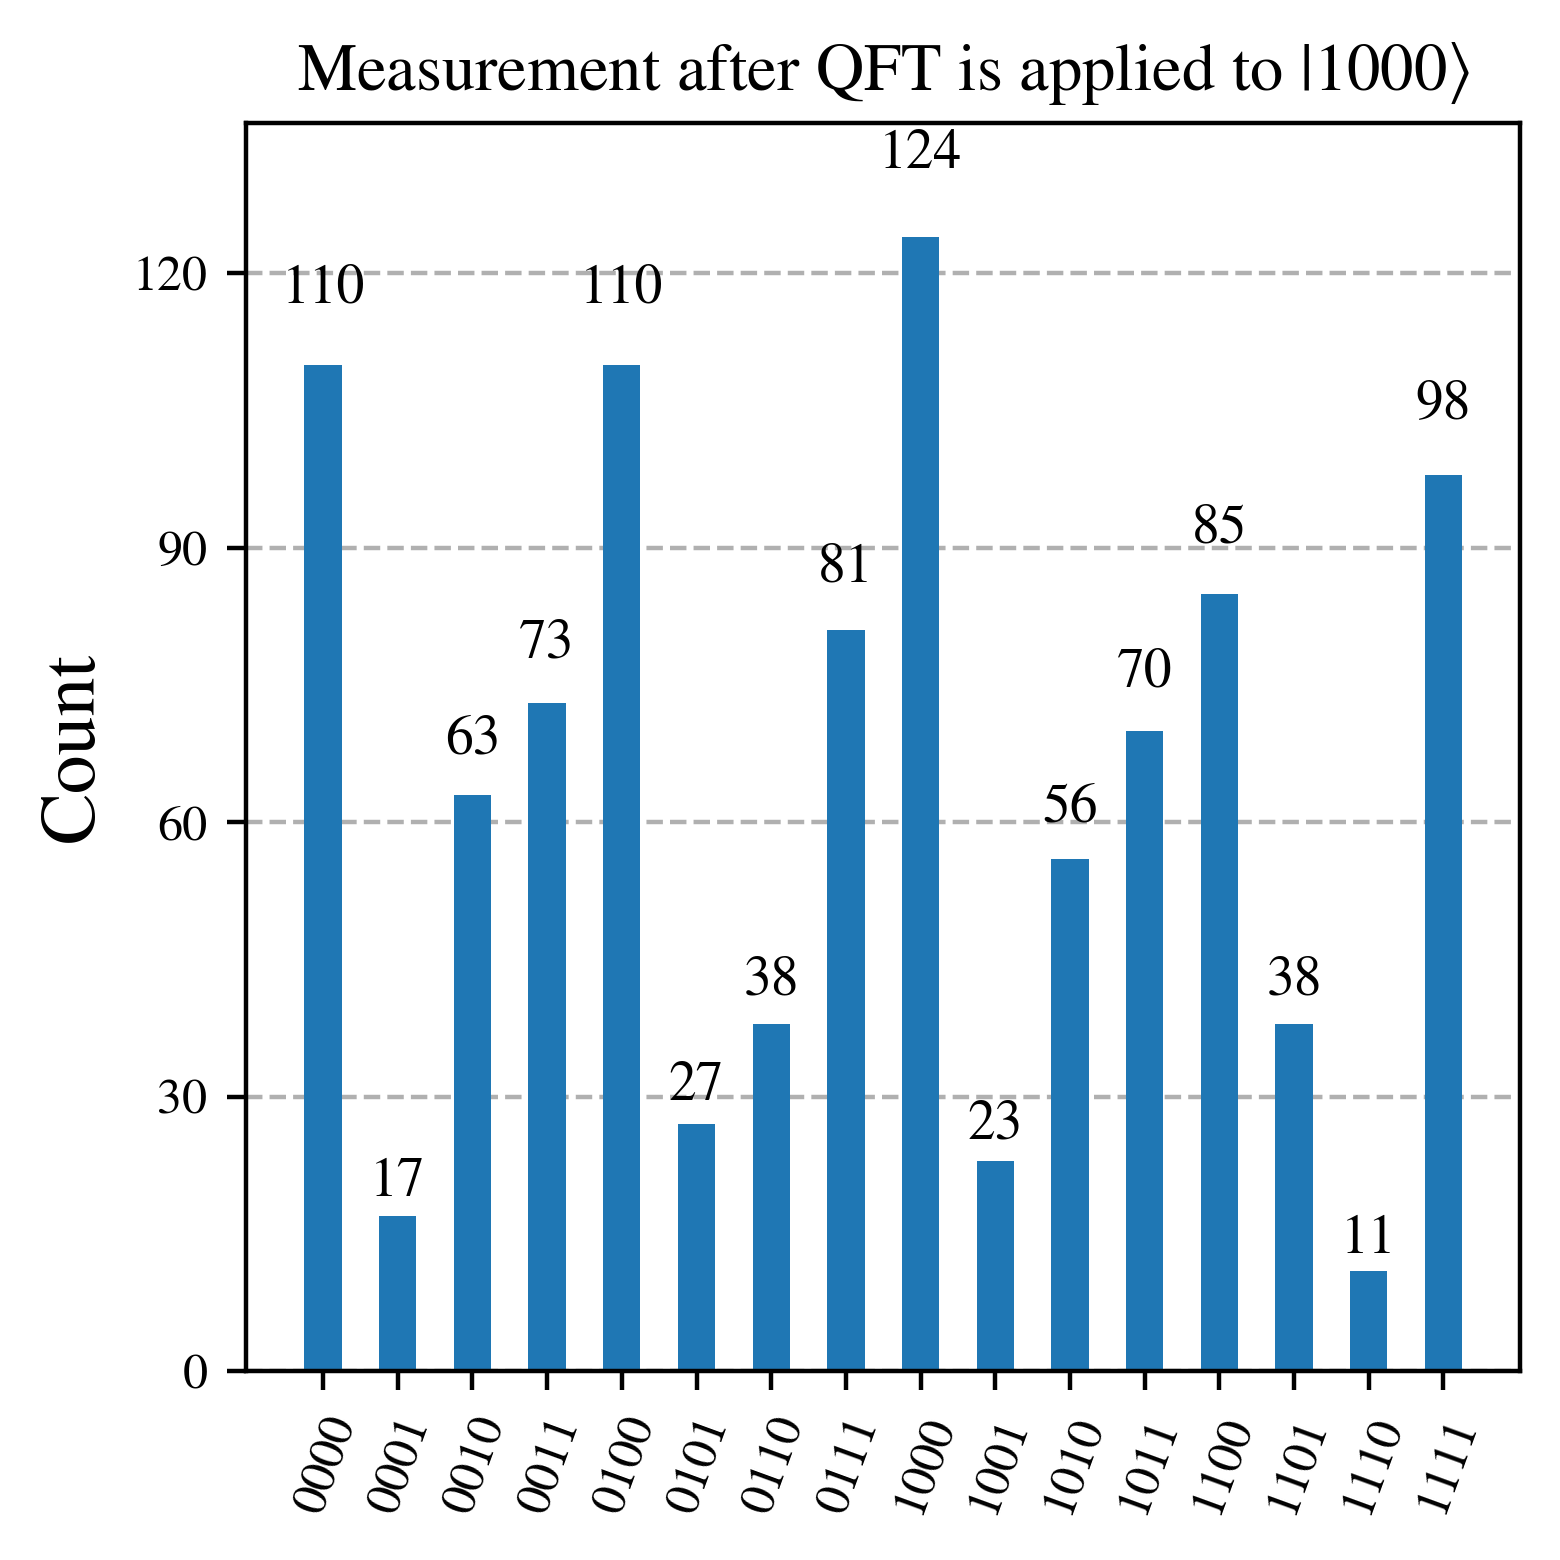

In [13]:
# Step 1: Create circuit
qc_qft = QuantumCircuit(4)
qc_qft.h(0)
qc_qft.compose(QFTGate(qubits), inplace=True)
qc_qft.measure_all()
fig=qc_qft.draw("mpl")
fig.show()

# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_qft)

# Step 3: Run the job on the Aer simulator with noise model from real backend

job = sampler_sim.run([qc_isa])
res = job.result()
counts = res[0].data.meas.get_counts()

# Step 4: Post-Process
fig= plot_histogram_reversed(counts, title=r"Measurement after QFT is applied to $\vert 1000 \rangle$")
fig.show()

### Inverse QFT following QFT

/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/4274297608.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_14058/4274297608.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


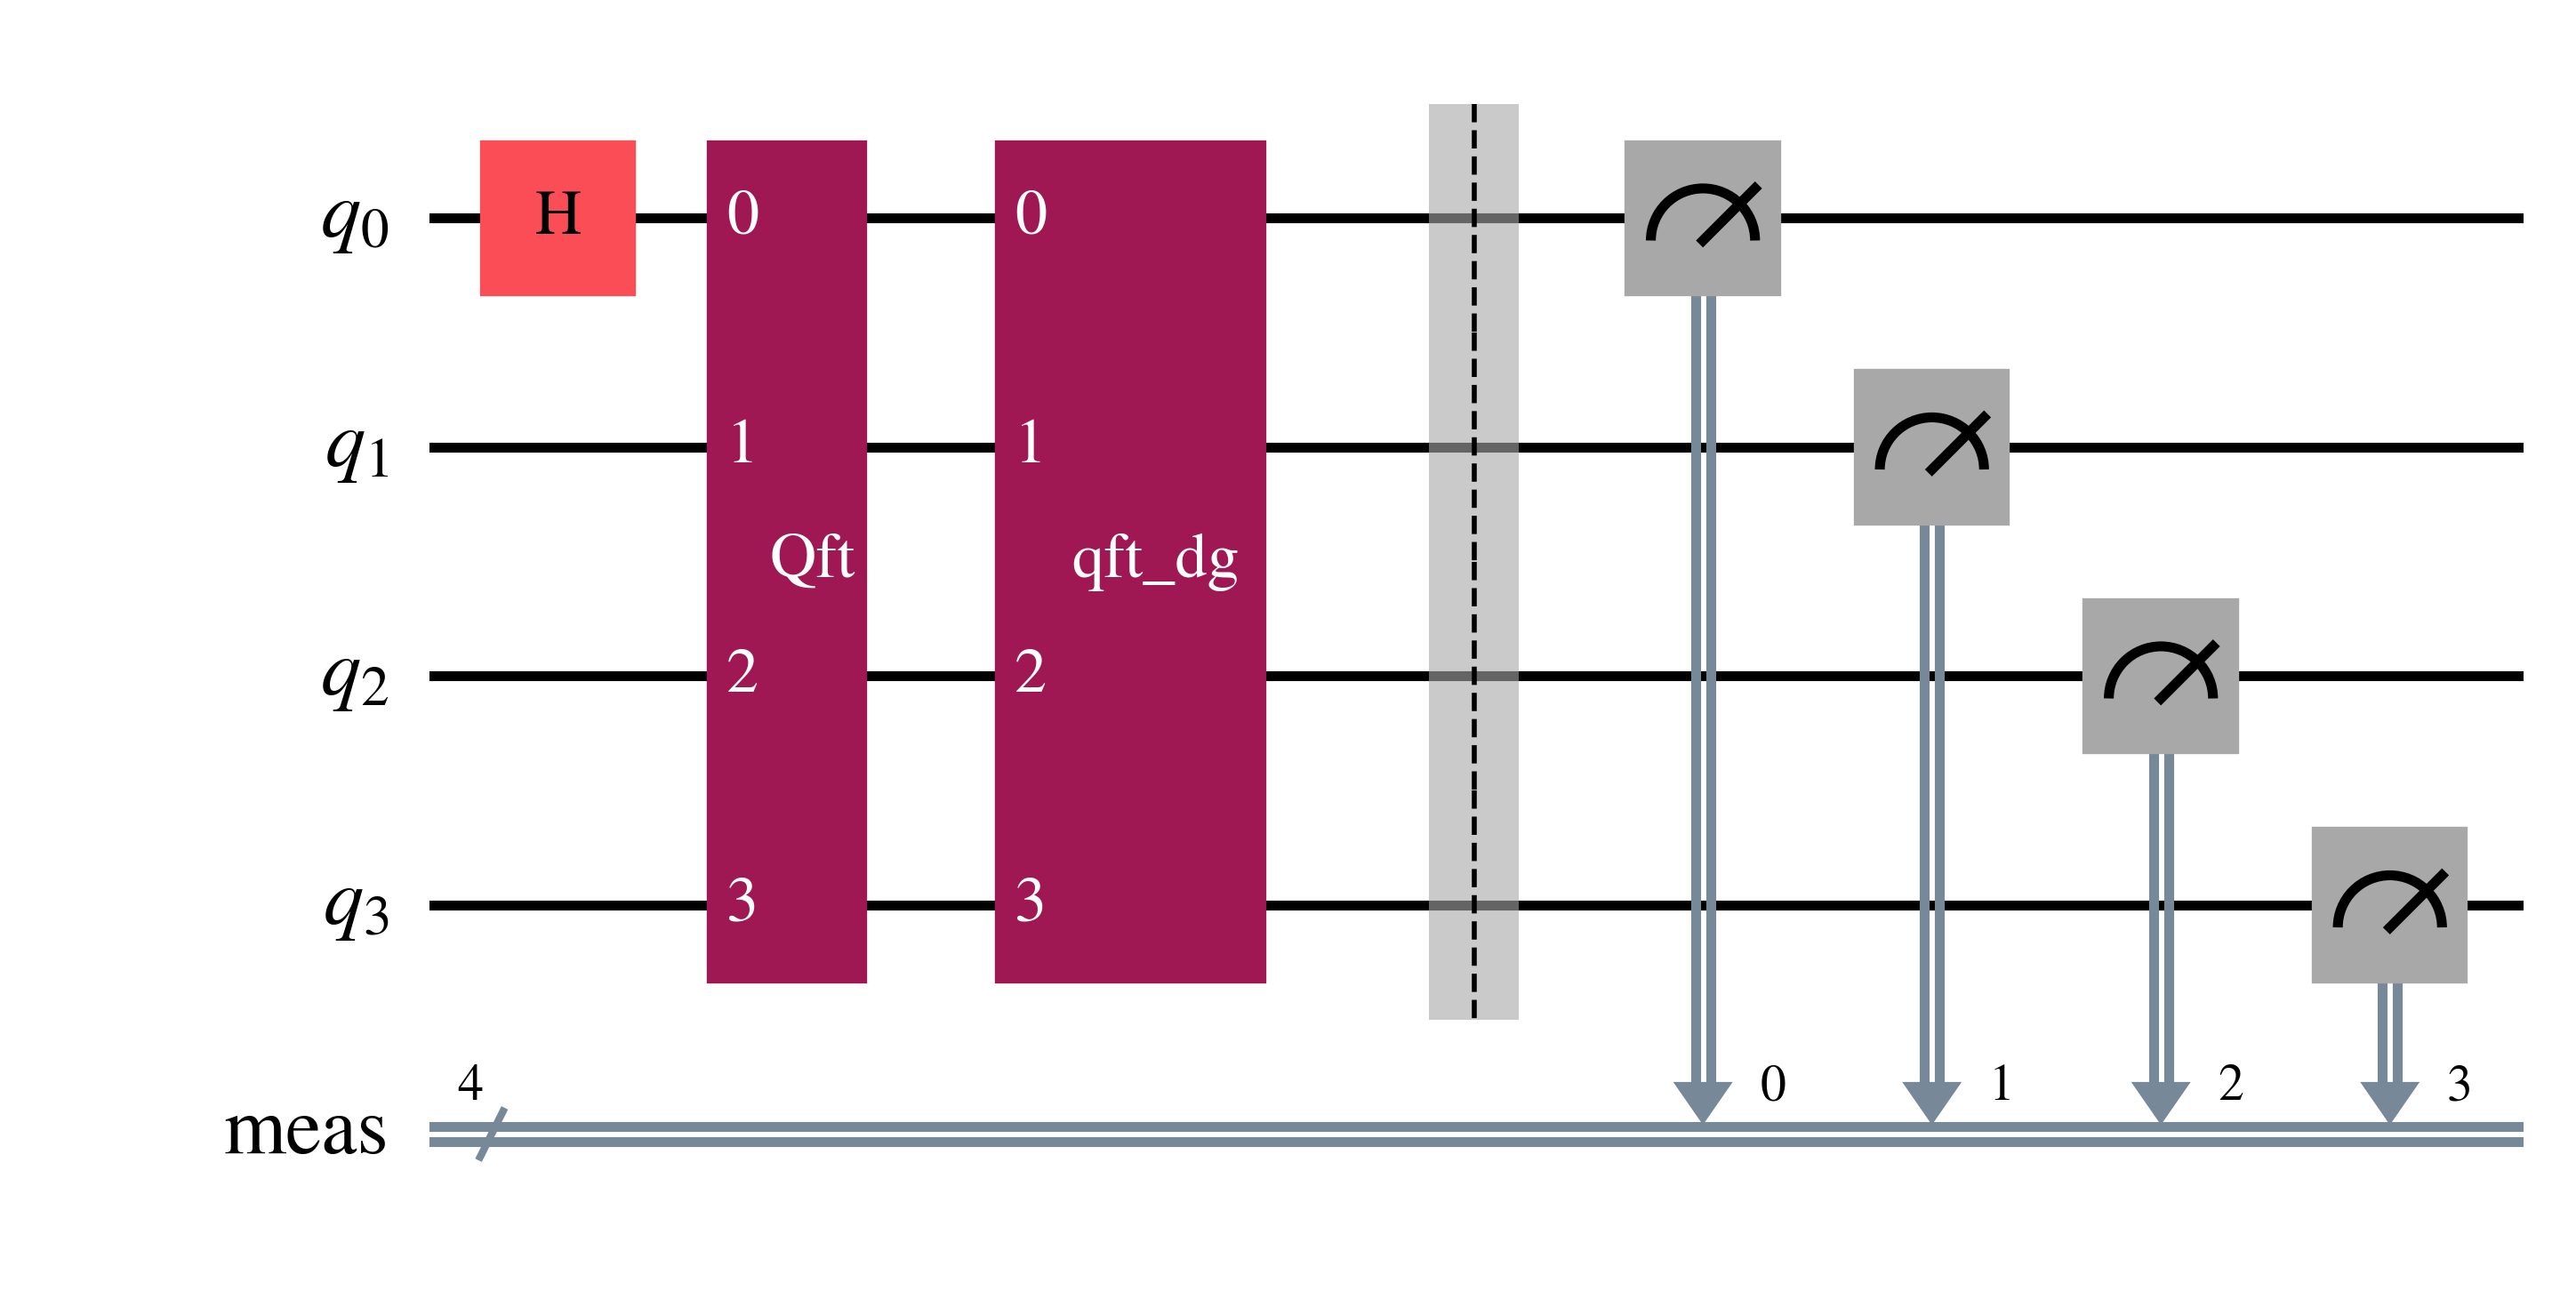

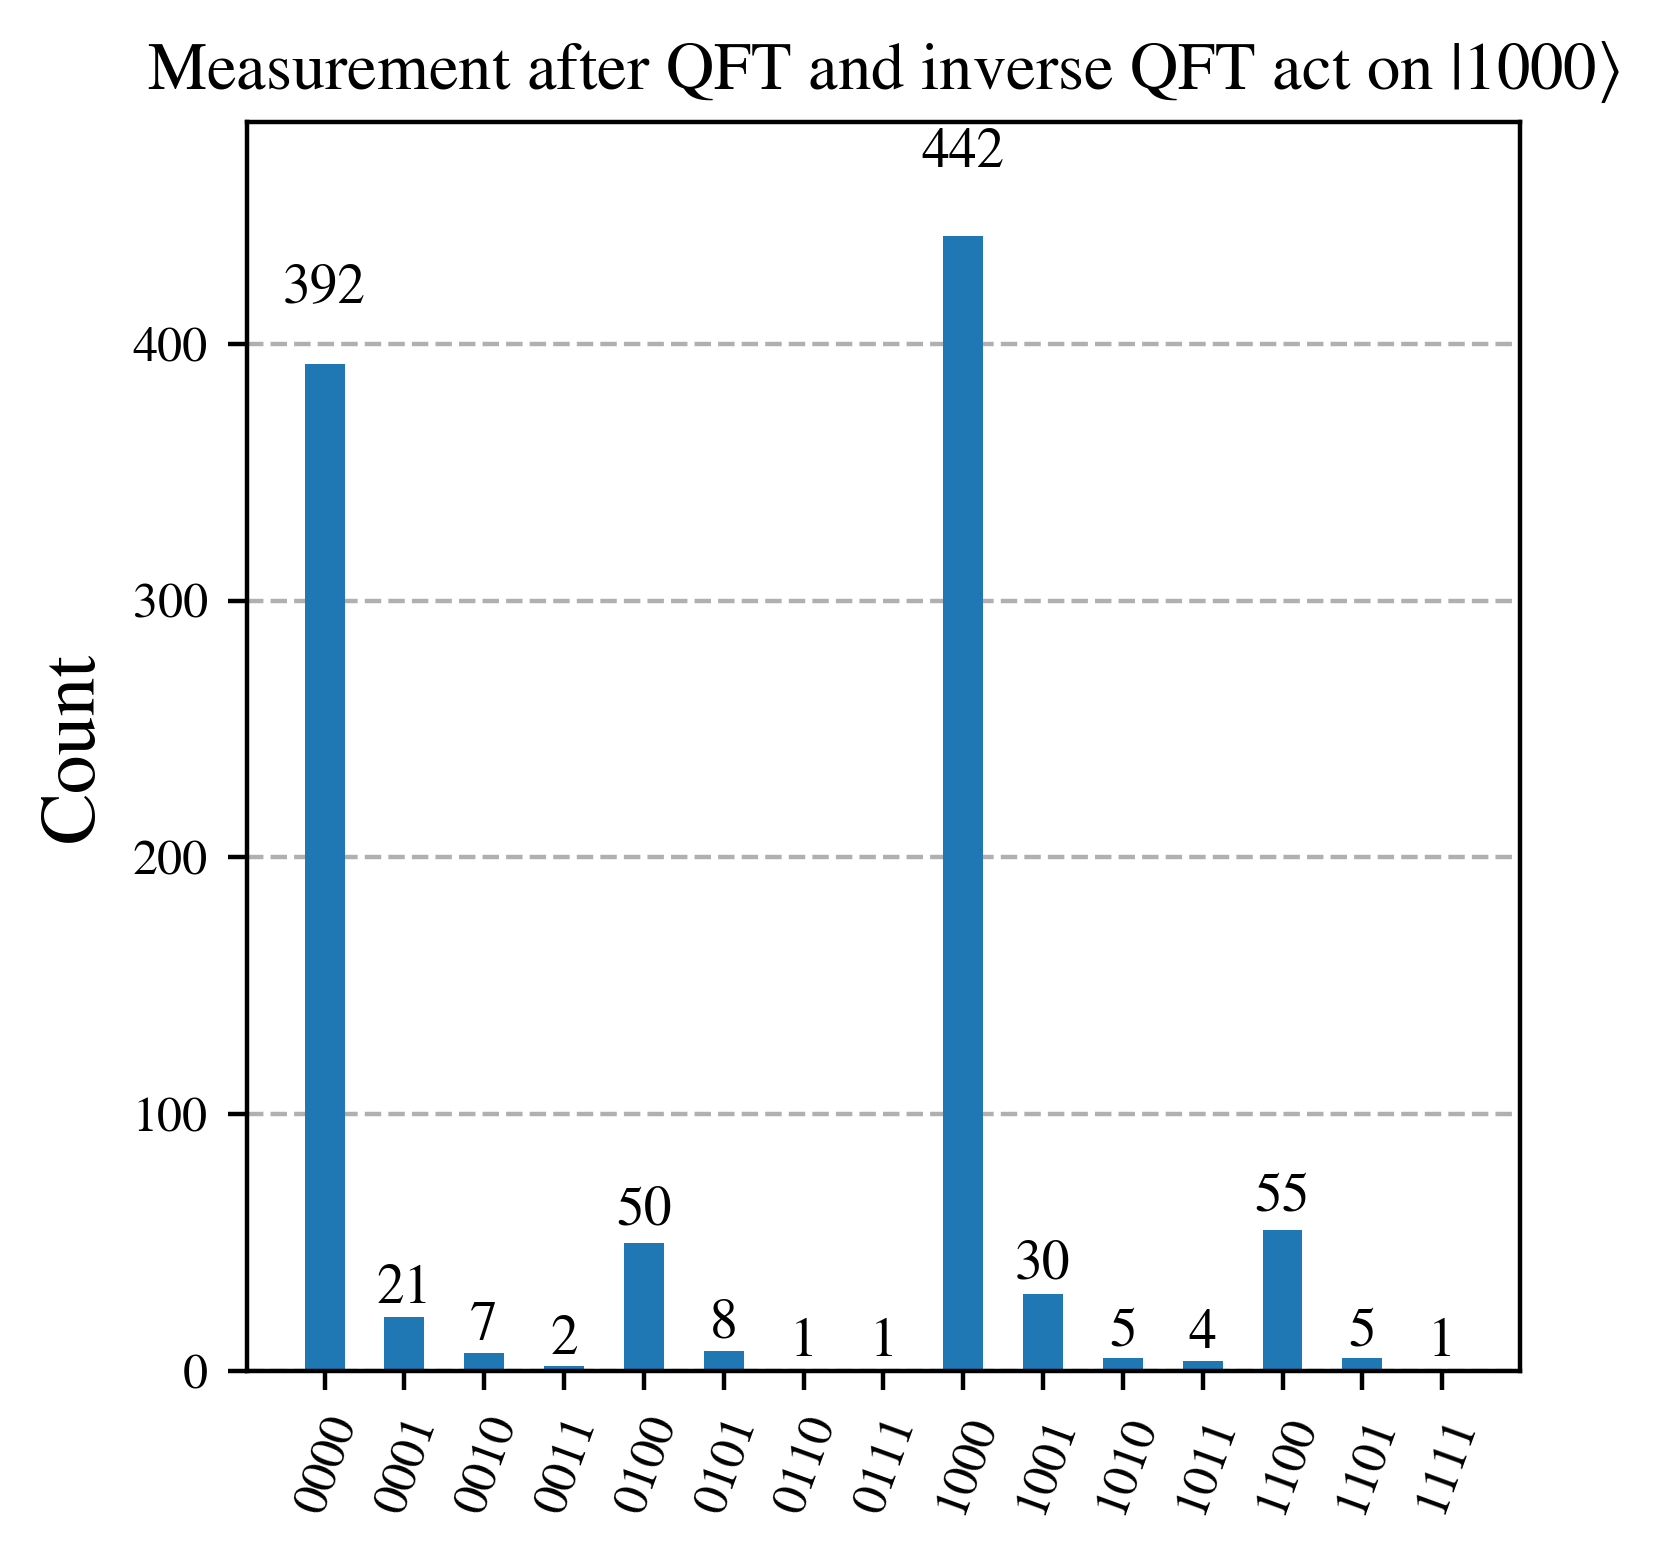

In [14]:
# Step 1: Create circuit
qc_qft = QuantumCircuit(4)
qc_qft.h(0)
qc_qft.compose(QFTGate(qubits), inplace=True)
qc_qft.compose(QFTGate(qubits).inverse(), inplace=True)
qc_qft.measure_all()
fig=qc_qft.draw("mpl")
fig.show()

# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_qft)

# Step 3: Run the job on the Aer simulator with noise model from real backend

job = sampler_sim.run([qc_isa])
res = job.result()
counts = res[0].data.meas.get_counts()

# Step 4: Post-Process
fig= plot_histogram_reversed(counts, title=r"Measurement after QFT and inverse QFT act on $\vert 1000 \rangle$")
fig.show()